# Phase 1 — Reddit Engagement Analysis

**Instructor:** Prof. Alexis Yanez  
**Due:** Tuesday, March 3rd, 2026

### Student Information
- **Name:** Affan Thameem  
- **Student ID:** 40282375
- **Section / Lab:** COMP 333 - GJ-X 
---
- **Name:** Mohammad Salah Sartawi
- **Student ID:** 40246396
- **Section / Lab:** COMP 333 - GJ-X
---
- **Name:** Chimdindu Okelekwe
- **Student ID:** 40153875
- **Section / Lab:**  COMP 333 - GI-X 

#### Objective & Research Questions

**RQ1 (Supervised):** Can we predict **high engagement** (score ≥ 80th percentile) from content and structural features?
- **Features:** `title_length`, `has_selftext`, `subreddit`, `post_type`, `hour_of_day`, `day_of_week`, `is_weekend`, `domain`

**RQ2 (Unsupervised):** Can we discover natural clusters of Reddit submissions based on engagement patterns, subreddit, and content structure  **without using the score label**?
- **Features:** `title_length`, `has_selftext`, `subreddit`, `post_type`, `hour_of_day`, `day_of_week`, `is_weekend`, `domain`


## 1. Prerequisites

1. Import all packages

#### Datasets
- Reddit comments/submissions 2026-01: https://academictorrents.com/details/8412b89151101d88c915334c45d9c223169a1a60
- Access dataset: https://transmissionbt.com/

---

#### Dataset Setup

1. Download the dataset zip file from the link below:

   -> [Download Dataset (Google Drive)](https://drive.google.com/file/d/1W6mqYfel_PRtVGaikCB-HepsuLJ4buWT/view)

2. Unzip the downloaded file to find `reddit_subset.jsonl` at the same level as the notebook:

```
project/
└── reddit_subset.jsonl
└── Phase_1.ipynb
```

---

#### Running the Notebook

Open `Phase_1.ipynb` in Jupyter and run all cells top to bottom.

> **Note:** The data extraction cell (Section 1.1) is already commented out, the dataset is pre-extracted. Do not uncomment or re-run it.

---

#### Notebook Structure

| Section | Description |
|---------|-------------|
| 1. Data Retrieval | Documents how the raw dataset was sourced and extracted |
| 2. Wrangling & Cleaning | Cleaning pipeline, feature engineering, and data quality checks |
| 3. EDA | Exploratory analysis of features and engagement patterns |
| 4. Baseline Model | Logistic regression baseline; train/val/test split; evaluation metrics |
| 5. Report | Summary of work and division of labour |

In [1]:
import zstandard as zstd
import json
import io
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re
import gdown
import zipfile
import os

pd.set_option('display.float_format', '{:.2f}'.format)

/Users/valerie/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### 1.1 Data Retrieval (Document Sources; Programmatic Retrieval; Challenges; Raw Storage)

#### **Document sources**

*   **Primary source:** Reddit submissions (January 2026) obtained from [Academic Torrents](https://academictorrents.com/details/8412b89151101d88c915334c45d9c223169a1a60) (Pushshift/Reddit data dump).
    
*   **Access method:** BitTorrent client (e.g., [Transmission](https://transmissionbt.com/)) to download the compressed `RS_2026-01.zst` file (~19.6 GB).
    

#### **Programmatic retrieval**

*   We use **file-based streaming extraction** (no API or SQL queries). 
*   The Python `zstandard` library decompresses the `.zst` archive and streams the data line-by-line.  
*   Each line represents one Reddit submission in JSON format.
*   During streaming:
    
    *   JSON lines are parsed using json.loads().
        
    *   NSFW posts (over\_18 = True) are excluded.
        
    *   Only a predefined subset of relevant fields is retained.
        
    *   Extraction stops once a ~2 GB subset is written to disk.
        

This streaming approach assures memory efficiency and avoids loading the full 19.6 GB archive into RAM.

#### **Handling challenges**

*   **Rate limits:** Not applicable - data is downloaded via torrent and processed locally.
    
*   **Authentication:** Not required - dataset is publicly available.
    
*   **Data quality:**
    
    *   NSFW content is filtered during extraction.
        
    *   Only fields required for research questions are retained to reduce noise and storage overhead.
        

#### **Raw data storage**

*   Output file: reddit\_subset.jsonl (~2 GB).
    
*   Format: JSON Lines (one Reddit submission per line).
    
*   The stored dataset does **not** preserve all original 152 fields; instead, it retains only the subset necessary for analysis:
    
    *   id
        
    *   subreddit
        
    *   created\_utc
        
    *   title
        
    *   selftext
        
    *   is\_self
        
    *   is\_video
        
    *   domain
        
    *   score
        

This storage strategy:

*   Ensures reproducibility while reducing unnecessary metadata.
    
*   Prevents data leakage by excluding post-engagement fields (e.g., comments, awards).
    
*   Preserves all variables required to derive structural and contextual features for both supervised (RQ1) and unsupervised (RQ2) analyses.
    
*   Maintains a manageable dataset size for local computation while remaining statistically representative.


**NO NEED TO RUN AGAIN**

In [2]:
# INPUT_FILE_PATH = "../Dataset/RS_2026-01.zst"
# OUTPUT_FILE_PATH = "reddit_subset.jsonl"
# TARGET_SIZE_BYTES = 2 * 1024**3  # 2GB

# FIELDS_TO_KEEP = [
#     "id",           # Unique post identifier (used for tracking/deduplication, not as a feature)
#     "subreddit",    # Captures community context and engagement norms
#     "created_utc",  # Used to derive time-based features (hour, day, weekend)
#     "title",        # Used to compute title length and optional text features
#     "selftext",     # Used to detect content presence and optional text features
#     "is_self",      # Indicates text post vs link post (post type feature)
#     "is_video",     # Indicates video content (post type feature)
#     "score",        # Used only to create high-engagement label (not as input feature)
#     "domain",       # Identifies external source platform for refining post type
# ]

# bytes_written = 0
# rows_written = 0

# with open(INPUT_FILE_PATH, "rb") as compressed_file:
#     decompressor = zstd.ZstdDecompressor()

#     with decompressor.stream_reader(compressed_file) as decompressed_stream:
#         text_stream = io.TextIOWrapper(decompressed_stream, encoding="utf-8", errors="replace")

#         with open(OUTPUT_FILE_PATH, "w", encoding="utf-8") as output_file:
#             for raw_line in tqdm(text_stream, desc="Extracting submissions"):
#                 submission = json.loads(raw_line)  # Will raise if malformed (handled in Part 2)

#                 # Filter out NSFW content
#                 if submission.get("over_18"):
#                     continue

#                 filtered_submission = {field: submission.get(field) for field in FIELDS_TO_KEEP}

#                 json_line = json.dumps(filtered_submission, ensure_ascii=False) + "\n"
#                 output_file.write(json_line)

#                 bytes_written += len(json_line.encode("utf-8"))
#                 rows_written += 1

#                 if bytes_written >= TARGET_SIZE_BYTES:
#                     break

# print("Done! Extracted ~2GB subset.")
# print(f"Rows written: {rows_written:,}")
# print(f"Total written: {bytes_written / (1024**3):.2f} GB")

##### Due to the large size of the dataset (~2.15GB), smaller subsets (500MB, 1GB, and 1.5GB) were created for efficient experimentation and demonstration, while preserving the original data format.

In [3]:
# def create_random_subsets(input_file, output_file, sample_ratio=0.25):
#     """
#     Random sampling for large JSONL files
#     """
#     with open(input_file, "r", encoding="utf-8") as infile, \
#          open(output_file, "w", encoding="utf-8") as outfile:

#         lines_written = 0

#         for line in infile:
#             if random.random() < sample_ratio:
#                 outfile.write(line)
#                 lines_written += 1

#     print(f"Random subset saved: {output_file}")
#     print(f"Lines written: {lines_written:,}")

In [4]:
# create_random_subsets("reddit_subset.jsonl", "reddit_500MB.jsonl", 0.25)
# create_random_subsets("reddit_subset.jsonl", "reddit_1GB.jsonl", 0.5)
# create_random_subsets("reddit_subset.jsonl", "reddit_1_5GB.jsonl", 0.7)

#### Select data set you with to run.

[dataset1 - 2.15 GB](https://drive.google.com/file/d/1W6mqYfel_PRtVGaikCB-HepsuLJ4buWT/view?usp=sharing): ~3.85M Posts

[dataset2 - 1.5 GB](https://drive.google.com/file/d/1uK1CG1nWNu00fkIQO5zrJbC02sITj7U7/view?usp=sharing): ~2.69M Posts

[dataset3 - 1 GB](https://drive.google.com/file/d/19afx8E9rm5nGQ3isregVp6Y_PwGq6tEx/view?usp=sharing): ~1.92M Posts

[dataset4 - 0.5 GB](https://drive.google.com/file/d/13TXBzK0r22c67FuWl7QQCCdvccXARQ1L/view?usp=sharing): ~0.96M Posts

In [5]:
def download_and_prepare_dataset(mode):
    datasets = {
        "full": {
            "name": "2.15GB",
            "file_id": "1W6mqYfel_PRtVGaikCB-HepsuLJ4buWT",
            "filename": "reddit_subset.zip",
            "is_zip": True
        },
        "large": {
            "name": "1.5GB",
            "file_id": "1uK1CG1nWNu00fkIQO5zrJbC02sITj7U7",
            "filename": "reddit_1_5GB.jsonl",
            "is_zip": False
        },
        "medium": {
            "name": "1GB",
            "file_id": "19afx8E9rm5nGQ3isregVp6Y_PwGq6tEx",
            "filename": "reddit_1GB.jsonl",
            "is_zip": False
        },
        "demo": {
            "name": "500MB",
            "file_id": "13TXBzK0r22c67FuWl7QQCCdvccXARQ1L",
            "filename": "reddit_500MB.jsonl",
            "is_zip": False
        }
    }

    if mode not in datasets:
        raise ValueError("Invalid mode")

    dataset = datasets[mode]
    filename = dataset["filename"]

    # 2. Extract if ZIP
    if dataset["is_zip"]:
        extracted_jsonl = None
        if os.path.exists(filename):
            with zipfile.ZipFile(filename, 'r') as zip_ref:
                for file in zip_ref.namelist():
                    if file.endswith(".jsonl") and os.path.exists(file):
                        extracted_jsonl = file
                        break

        if extracted_jsonl:
            print(f" Already extracted. Using: {extracted_jsonl}")
            return extracted_jsonl

        # Download if zip not present
        if not os.path.exists(filename):
            print(f" Downloading {dataset['name']} dataset...")
            url = f"https://drive.google.com/uc?id={dataset['file_id']}"
            gdown.download(url, filename, quiet=False)

        print(" Extracting ZIP...")
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall()
            for file in zip_ref.namelist():
                if file.endswith(".jsonl"):
                    print(f" Using: {file}")
                    return file

    else:
        # For plain .jsonl files, skip download if file already exists
        if os.path.exists(filename):
            print(f" File already exists. Using: {filename}")
            return filename

        print(f" Downloading {dataset['name']} dataset...")
        url = f"https://drive.google.com/uc?id={dataset['file_id']}"
        gdown.download(url, filename, quiet=False)

    print(f" Using: {filename}")
    return filename

In [6]:
# mode="full"     2.15GB 
# mode="large"    1.5GB
# mode="medium"   1GB
# mode="demo"     500MB

INPUT_FILE = download_and_prepare_dataset("demo")

 File already exists. Using: reddit_500MB.jsonl


---

## 2. Wrangling & Cleaning

This section performs an **initial audit** (missing values, duplicates, outliers) and applies a **reproducible cleaning pipeline**. We use `quantDDA()` and `vizDDA()` from Lab 2 for quantitative and visual data quality checks.

### 2.1 Initial Audit (Missing, Duplicates, Outliers)

In [7]:
def audit_dataframe(df):
    """Initial audit: missing values, duplicates, basic outlier context."""
    return {
        "shape": df.shape,
        "missing": df.isnull().sum().sort_values(ascending=False),
        "missing_pct": (df.isnull().mean() * 100).round(2).sort_values(ascending=False),
        "duplicate_ids": df["id"].duplicated().sum() if "id" in df.columns else 0,
        "dtypes": df.dtypes
    }

df = pd.read_json(INPUT_FILE, lines=True)
audit = audit_dataframe(df)
print("Shape:", audit["shape"])

print("\n=== COLUMN DTYPES ===")
print(audit["dtypes"])

print("\n=== TOP MISSING VALUES (count) ===")
print(audit["missing"].head(20))

print("\n=== TOP MISSING VALUES (%) ===")
print(audit["missing_pct"].head(20))

print("\n=== DUPLICATES ===")
print("Duplicate IDs:", audit["duplicate_ids"])

# Score distribution checks (target variable source)
print("\n=== SCORE DESCRIBE ===")
print(df["score"].describe())

print("\n=== SCORE QUANTILES ===")
print(df["score"].quantile([0.5, 0.75, 0.8, 0.9, 0.95]))

print("\n=== FIRST 20 ROWS ===")
display(df.head(20))

Shape: (962586, 9)

=== COLUMN DTYPES ===
id             object
subreddit      object
created_utc     int64
title          object
selftext       object
is_self          bool
is_video         bool
score           int64
domain         object
dtype: object

=== TOP MISSING VALUES (count) ===
id             0
subreddit      0
created_utc    0
title          0
selftext       0
is_self        0
is_video       0
score          0
domain         0
dtype: int64

=== TOP MISSING VALUES (%) ===
id            0.00
subreddit     0.00
created_utc   0.00
title         0.00
selftext      0.00
is_self       0.00
is_video      0.00
score         0.00
domain        0.00
dtype: float64

=== DUPLICATES ===
Duplicate IDs: 0

=== SCORE DESCRIBE ===
count   962586.00
mean        52.08
std        600.02
min          0.00
25%          1.00
50%          1.00
75%          9.00
max      89900.00
Name: score, dtype: float64

=== SCORE QUANTILES ===
0.50     1.00
0.75     9.00
0.80    14.00
0.90    54.00
0.95   146.0

,id,subreddit,created_utc,title,selftext,is_self,is_video,score,domain
0,1q0quu5,fanduel,1767225600,Not likely but you never know,,False,False,2,i.redd.it
1,1q0quu9,FishingPlanet,1767225600,How do you setup the saltwater silicone squids ?,Can not setup the saltwater silicone squids an...,True,False,1,self.FishingPlanet
2,1q0quur,PokemonTCG,1767225601,My destined rivals luck 🍀,Omg I’ve been pulling destined rivals lately a...,False,False,6,i.redd.it
3,1q0quus,canadaguns,1767225601,scammer pretending to be Podzols on gunpost (s...,he refused to go on gunpost and reply to the m...,False,False,55,reddit.com
4,1q0quux,lootofolympus_dev,1767225601,⚡ Loot of Olympus – 01 Jan 2026 @ 00:00 ⚡,This post contains content not supported on ol...,True,False,1,self.lootofolympus_dev
5,1q0quv0,u_RainKateTagral,1767225601,Sobrevivir En La Isla De La Piñata,Trata de una piñata que fue creada por una tri...,False,False,1,i.redd.it
6,1q0quv9,Jigzle,1767225601,"[Jigzle] Daily Challenge - January 1, 2026",This post contains content not supported on ol...,True,False,2,self.Jigzle
7,1q0quvc,WhereAmIGame,1767225601,"Daily Challenge – January 01, 2026",,False,False,1,whereamigame.app
8,1q0quve,SouthwestAirlines,1767225601,Forbes article praising Southwest changes,[https://www.forbes.com/sites/mikeboyd/2025/12...,True,False,33,self.SouthwestAirlines
9,1q0quvu,podiumgame,1767225602,"Podium Game for December 31, 2025",This post contains content not supported on ol...,True,False,1,self.podiumgame


---

### 2.2 Reproducible Cleaning Pipeline (RQ1 & RQ2)

For consistency and reproducibility across both research questions, we implemented preprocessing function, `clean_reddit_data()`, which normalizes the dataset and engineers structural features required for analysis.

The raw dataset contains the following retained fields:`id`, `subreddit`, `created\_utc`, `title`, `selftext`, `is_self`, `is_video`, `domain`, and `score`.

From these raw fields, additional columns are created:

*   `high_engagement` -> binary target variable defined as score ≥ 80th percentile
    
*   `title_length` -> character length of the submission title
    
*   `has_selftext` -> binary indicator of whether body content is present
    
*   `post_type` -> categorical feature derived from is\_self and is\_video (self, video, or link)
    
*   `hour_of_day` -> UTC hour extracted from created\_utc
    
*   `day_of_week` -> weekday index (0–6)
    
*   `is_weekend` -> binary weekend indicator
    

#### Target Definition (RQ1 - Supervised Learning)

Reddit engagement follows a heavy right-skewed distribution. To reduce skew effects and produce a stable classification task, high engagement is defined as submissions with a score at or above the 80th percentile of the score distribution. This percentile-based thresholding produces the binary variable `high_engagement`.

#### RQ1 (Supervised Modeling)

The engineered structural features (`title_length`, `has_selftext`, `subreddit`, `post_type`, `hour_of_day`, `day_of_week`, `is_weekend`, and `domain`) are used to predict the binary outcome `high_engagement`.

#### RQ2 (Unsupervised Clustering)

The same structural and contextual features are used for clustering analysis. The engagement variable (`score`) and derived label (`high_engagement`) are excluded from clustering inputs to prevent information leakage and avoid biased or inflated evaluation outcomes. After forming clusters without using score, we examine how engagement varies across clusters to understand what each cluster represents.

#### Reproducibility Guarantees

The cleaning pipeline ensures reproducibility by:

*   Applying deterministic feature transformations
    
*   Explicitly defining derived columns
    
*   Handling missing values consistently
    
*   Removing duplicate submission IDs
    
*   Using identical preprocessing logic for both RQ1 and RQ2

In [8]:
# Reproducible pipeline: features aligned with RQ1 (supervised) and RQ2 (unsupervised)
def clean_reddit_data(raw_path_or_df, engagement_quantile: float = 0.80) -> pd.DataFrame:
    """Clean Reddit dataset + create label + engineer features (leak-free safe stage)."""

    raw_df = (pd.read_json(raw_path_or_df, lines=True) if isinstance(raw_path_or_df, str) else raw_path_or_df.copy())

    df = raw_df.copy()
    
    # 1. Basic normalization
    df["title"] = df["title"].fillna("").astype(str).str.strip()
    df["selftext"] = df["selftext"].fillna("").astype(str).str.strip()
    df["domain"] = df["domain"].fillna("")

    # Remove empty titles 
    df = df[df["title"] != ""]

    # 2. Fix Reddit-specific missing values
    def is_invalid_text(text):
        text = str(text).lower().strip()
        text = re.sub(r'[\[\](){}]', '', text)  # remove brackets
        text = re.sub(r'\s+', ' ', text)        # normalize spaces

        return text == "" or "removed" in text or "deleted" in text
    
    df = df[~df["title"].apply(is_invalid_text)]
    df["has_selftext"] = ~df["selftext"].apply(is_invalid_text)
    df["has_selftext"] = df["has_selftext"].astype(int)

    # 3. Target label (RQ1)
    threshold = df["score"].quantile(engagement_quantile)
    df["high_engagement"] = (df["score"] >= threshold).astype(int)

    # 4. Feature engineering
    df["title_length"] = df["title"].str.len()

    # Updated: content type (replaces post_type)
    df["content_type"] = np.select(
        [
            df["is_self"].astype(bool),
            df["is_video"].astype(bool),
            df["domain"].str.contains("i.redd.it", na=False),
            df["domain"].str.contains("v.redd.it", na=False),
        ],
        [
            "text",
            "video",
            "image",
            "video",  # reddit video domain
        ],
        default="link"
    )
    df["post_type"] = df["content_type"]  # alias: RQ1 / viz / models use this name

    # Time features
    created_dt = pd.to_datetime(df["created_utc"], unit="s", utc=True, errors="coerce")
    df["hour_of_day"] = created_dt.dt.hour
    df["day_of_week"] = created_dt.dt.dayofweek
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    # 5. Handle outliers
    def cap_outliers(series, lower_q=0.01, upper_q=0.99):
        lower = series.quantile(lower_q)
        upper = series.quantile(upper_q)
        return series.clip(lower, upper)

    df["score"] = cap_outliers(df["score"])
    df["title_length"] = cap_outliers(df["title_length"])


    # 6. Remove duplicates
    df = df.drop_duplicates(subset=["id"], keep="first")


    # 7. Final cleanup
    df = df.dropna(subset=["hour_of_day", "day_of_week"])

    return df

def get_rq2_features(df_clean: pd.DataFrame) -> pd.DataFrame:
    """RQ2 clustering matrix: excludes score + label."""
    rq2_cols = [
        "subreddit",
        "title_length",
        "has_selftext",
        "content_type",  # updated
        "hour_of_day",
        "day_of_week",
        "is_weekend",
        "domain"
    ]
    return df_clean[rq2_cols].copy()


# Run cleaning pipeline on the full dataset
df_clean = clean_reddit_data(INPUT_FILE, engagement_quantile=0.80)
threshold = df_clean["score"].quantile(0.80)

print("Cleaned shape:", df_clean.shape)
print("High engagement threshold (80th %):", threshold)
print("Target distribution:", df_clean["high_engagement"].value_counts(normalize=True).to_dict())
print("Columns:", df_clean.columns.tolist())

df_rq2 = get_rq2_features(df_clean)
print("RQ2 feature shape:", df_rq2.shape)


Cleaned shape: (955903, 17)
High engagement threshold (80th %): 15.0
Target distribution: {0: 0.7998510309100401, 1: 0.20014896908995997}
Columns: ['id', 'subreddit', 'created_utc', 'title', 'selftext', 'is_self', 'is_video', 'score', 'domain', 'has_selftext', 'high_engagement', 'title_length', 'content_type', 'post_type', 'hour_of_day', 'day_of_week', 'is_weekend']
RQ2 feature shape: (955903, 8)


### 2.3 quantDDA() and vizDDA() (from Lab 2)

We use the `quantDDA()` and `vizDDA()` functions from Lab 2 for quantitative and visual data quality checks. `quantDDA` reports missing values, outliers (IQR), skewness, kurtosis; `vizDDA` produces histograms, scatter plots, boxplots, and heatmaps.

In [9]:
def quantDDA(df):
    summary_list = []  # List to store summary dictionaries

    for col in df.columns:  # Loop through each column in the DataFrame
        series = df[col]  
        
        # Basic counts (for all features)
        n_obs = len(series)                     # Total number of observations (rows)
        n_entries = series.count()              # Number of non-missing values (entries)
        n_unique = series.nunique(dropna=True)  # Number of unique non-missing values
        n_missing = series.isna().sum()         # Number of missing (NaN) values

        # Mode(s): most frequent value(s)
        if n_unique == n_entries:  
            modes = "No mode (all values unique)"  # No mode if every value appears once
        else:
            modes = series.dropna().mode().tolist()  # Most frequent value(s), ignoring NaN
            
        # Dictionary with universal statistics
        summary = {
            "Feature": col,                     # Feature (column) name
            "Observations": int(n_obs),         # Total observations in the dataset
            "Entries": int(n_entries),          # Non-missing values in this feature
            "Unique": int(n_unique),            # Unique values count
            "Missing": int(n_missing),          # Missing values count
            "Mode(s)": modes                    # Most common value(s)
        }

        # Compute numeric statistics only for numeric columns
        if pd.api.types.is_numeric_dtype(series) and not pd.api.types.is_bool_dtype(series):   # Check if column contains numbers
            clean = series.dropna()                 # Remove missing values

            if len(clean) > 0:                      # Only compute if column is not empty

                # Quartiles
                q1 = clean.quantile(0.25)           # First quartile (25th percentile)
                q2 = clean.quantile(0.50)           # Median (50th percentile)
                q3 = clean.quantile(0.75)           # Third quartile (75th percentile)

                # IQR Outlier bounds
                iqr = q3 - q1                       # Interquartile range
                lower = q1 - 1.5 * iqr              # Lower outlier boundary
                upper = q3 + 1.5 * iqr              # Upper outlier boundary

                # Extreme value thresholds (top/bottom 1%)
                lower_ext = clean.quantile(0.01)    # Bottom 1% threshold
                upper_ext = clean.quantile(0.99)    # Top 1% threshold

                # Update dictionary with numeric-only stats
                summary.update({
                    "Mean": clean.mean(),           # Average value
                    "Standard Deviation": clean.std(),             # Standard deviation
                    "Minimum": clean.min(),             # Minimum value
                    "Maximum": clean.max(),             # Maximum value
                    "First Quartile": q1,                       # 25th percentile
                    "Median": q2,              # Median (50th percentile)
                    "Third Quartile": q3,                       # 75th percentile
                    "Skewness": clean.skew() if len(clean) > 2 else np.nan,                     #  Measures distribution asymmetry
                    "Kurtosis": clean.kurt() if len(clean) > 3 else np.nan,                     # Measures tail heaviness / peakedness
                    "Outliers": int(((clean < lower) | (clean > upper)).sum()),                 # Values outside IQR boundaries
                    "Extreme (1%)": int(((clean <= lower_ext) | (clean >= upper_ext)).sum())    # Values in top/bottom 1% of distribution
                })

        summary_list.append(summary) 

    return pd.DataFrame(summary_list)


In [10]:
# Audit RQ1/RQ2 numeric features
quantDDA(df_clean)

,Feature,Observations,Entries,Unique,Missing,Mode(s),Mean,Standard Deviation,Minimum,Maximum,First Quartile,Median,Third Quartile,Skewness,Kurtosis,Outliers,Extreme (1%)
0,id,955903,955903,955903,0,No mode (all values unique),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,subreddit,955903,955903,103084,0,[chessquiz],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,created_utc,955903,955903,378828,0,[1767651576],1767449629.68,124600.32,1767225600.00,1767658319.00,1767344488.00,1767453665.00,1767557378.50,-0.03,-1.19,0.00,19123.00
3,title,955903,955903,844983,0,[Find the best position in 2 moves],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,selftext,955903,955903,523547,0,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,is_self,955903,955903,2,0,[False],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,is_video,955903,955903,2,0,[False],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,score,955903,955903,810,0,[1],30.41,107.40,0.00,809.00,1.00,1.00,9.00,5.60,33.80,159092.00,106474.00
8,domain,955903,955903,79042,0,[i.redd.it],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,has_selftext,955903,955903,2,0,[1],0.56,0.50,0.00,1.00,0.00,1.00,1.00,-0.25,-1.94,0.00,955903.00


In [11]:
def vizDDA(name, df):
    print(f"\n{'=' * 80}\n{name}\n{'=' * 80}")

    df_plot = df.copy()

    max_unique = 10  # Set to 500 to see all columns. Set to 10 for visual purposes (only low-cardinality categorical). Adjust as needed.

    def safe_nunique(s):
        try:
            return s.nunique(dropna=True)
        except (TypeError, ValueError):
            return float('inf')  # Skip columns with unhashable types

    keep_cols = [
        col for col in df_plot.columns
        if pd.api.types.is_numeric_dtype(df_plot[col]) or safe_nunique(df_plot[col]) <= max_unique
    ]  # Keep numeric always + only low-cardinality categorical

    df_plot = df_plot[keep_cols]  # Filter df for readable plotting

    cols = df_plot.columns.tolist()  # Column names used in grid
    n = len(cols)  # Grid size (n x n)

    numeric_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()  # Numeric columns
    categorical_cols = [c for c in cols if c not in numeric_cols]  # Categorical columns (low-cardinality)

    print("Columns used in grid:", cols)

    fig, axes = plt.subplots(n, n, figsize=(4 * n, 4 * n))  # Create plot grid
    if n == 1:
        axes = np.array([[axes]]) 

    # Loop through grid
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]  # Current subplot
            row_var = cols[i]  # Y variable
            col_var = cols[j]  # X variable

            # Matrix headers 
            if i == 0:
                ax.set_title(col_var)  # Column headers
            if j == 0:
                ax.set_ylabel(row_var)  # Row headers
            else:
                ax.set_ylabel("")  # Reduce clutter

            if i != n - 1:
                ax.set_xlabel("")  # Hide x-label except bottom row

            # Diagonal: Univariate
            if i == j:
                if row_var in numeric_cols:
                    df_plot[row_var].dropna().hist(ax=ax, bins=30, edgecolor="black")
                    cell_label = f"{row_var} (hist)"  # Cell meaning
                else:
                    df_plot[row_var].value_counts().plot(kind="bar", ax=ax)
                    ax.tick_params(axis="x", rotation=45)
                    cell_label = f"{row_var} (bar)"  # Cell meaning

            # Off-diagonal: Bivariate
            else:
                # Numeric vs Numeric -> Scatter
                if row_var in numeric_cols and col_var in numeric_cols:
                    ax.scatter(df_plot[col_var], df_plot[row_var], alpha=0.5, s=15)
                    cell_label = f"{row_var} vs {col_var} (scatter)"  # Cell meaning

                # Numeric vs Categorical -> Boxplot
                elif row_var in numeric_cols and col_var in categorical_cols:
                    sns.boxplot(x=df_plot[col_var], y=df_plot[row_var], ax=ax)
                    ax.tick_params(axis="x", rotation=45)
                    cell_label = f"{row_var} by {col_var} (box)"  # Cell meaning

                # Categorical vs Numeric -> Boxplot (variables flipped)
                elif row_var in categorical_cols and col_var in numeric_cols:
                    sns.boxplot(x=df_plot[row_var], y=df_plot[col_var], ax=ax)
                    ax.tick_params(axis="x", rotation=45)
                    cell_label = f"{col_var} by {row_var} (box)"  # Cell meaning

                # Categorical vs Categorical -> Heatmap
                else:
                    ct = pd.crosstab(df_plot[row_var], df_plot[col_var])
                    sns.heatmap(
                        ct,
                        annot=True,
                        fmt="d",
                        cbar=False,
                        ax=ax,
                        annot_kws={"color": "white"}  # Heatmap numbers in white
                    )
                    ax.tick_params(axis="x", rotation=45)
                    cell_label = f"{row_var} x {col_var} (count)"  # Cell meaning

            # Labeling
            ax.text(
                0.02, 0.95, cell_label,  # Position inside axes (top-left)
                transform=ax.transAxes,
                fontsize=9,
                va="top",
                ha="left",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none") # styling
            )

    plt.tight_layout()
    plt.show()

    # Missing values heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_plot.isna(), cbar=False)
    plt.title("Missing Values Heatmap")
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.tight_layout()
    plt.show()



DDA Visual Diagnostics (key features)
Columns used in grid: ['score', 'high_engagement', 'title_length', 'has_selftext', 'hour_of_day', 'day_of_week', 'is_weekend', 'post_type']


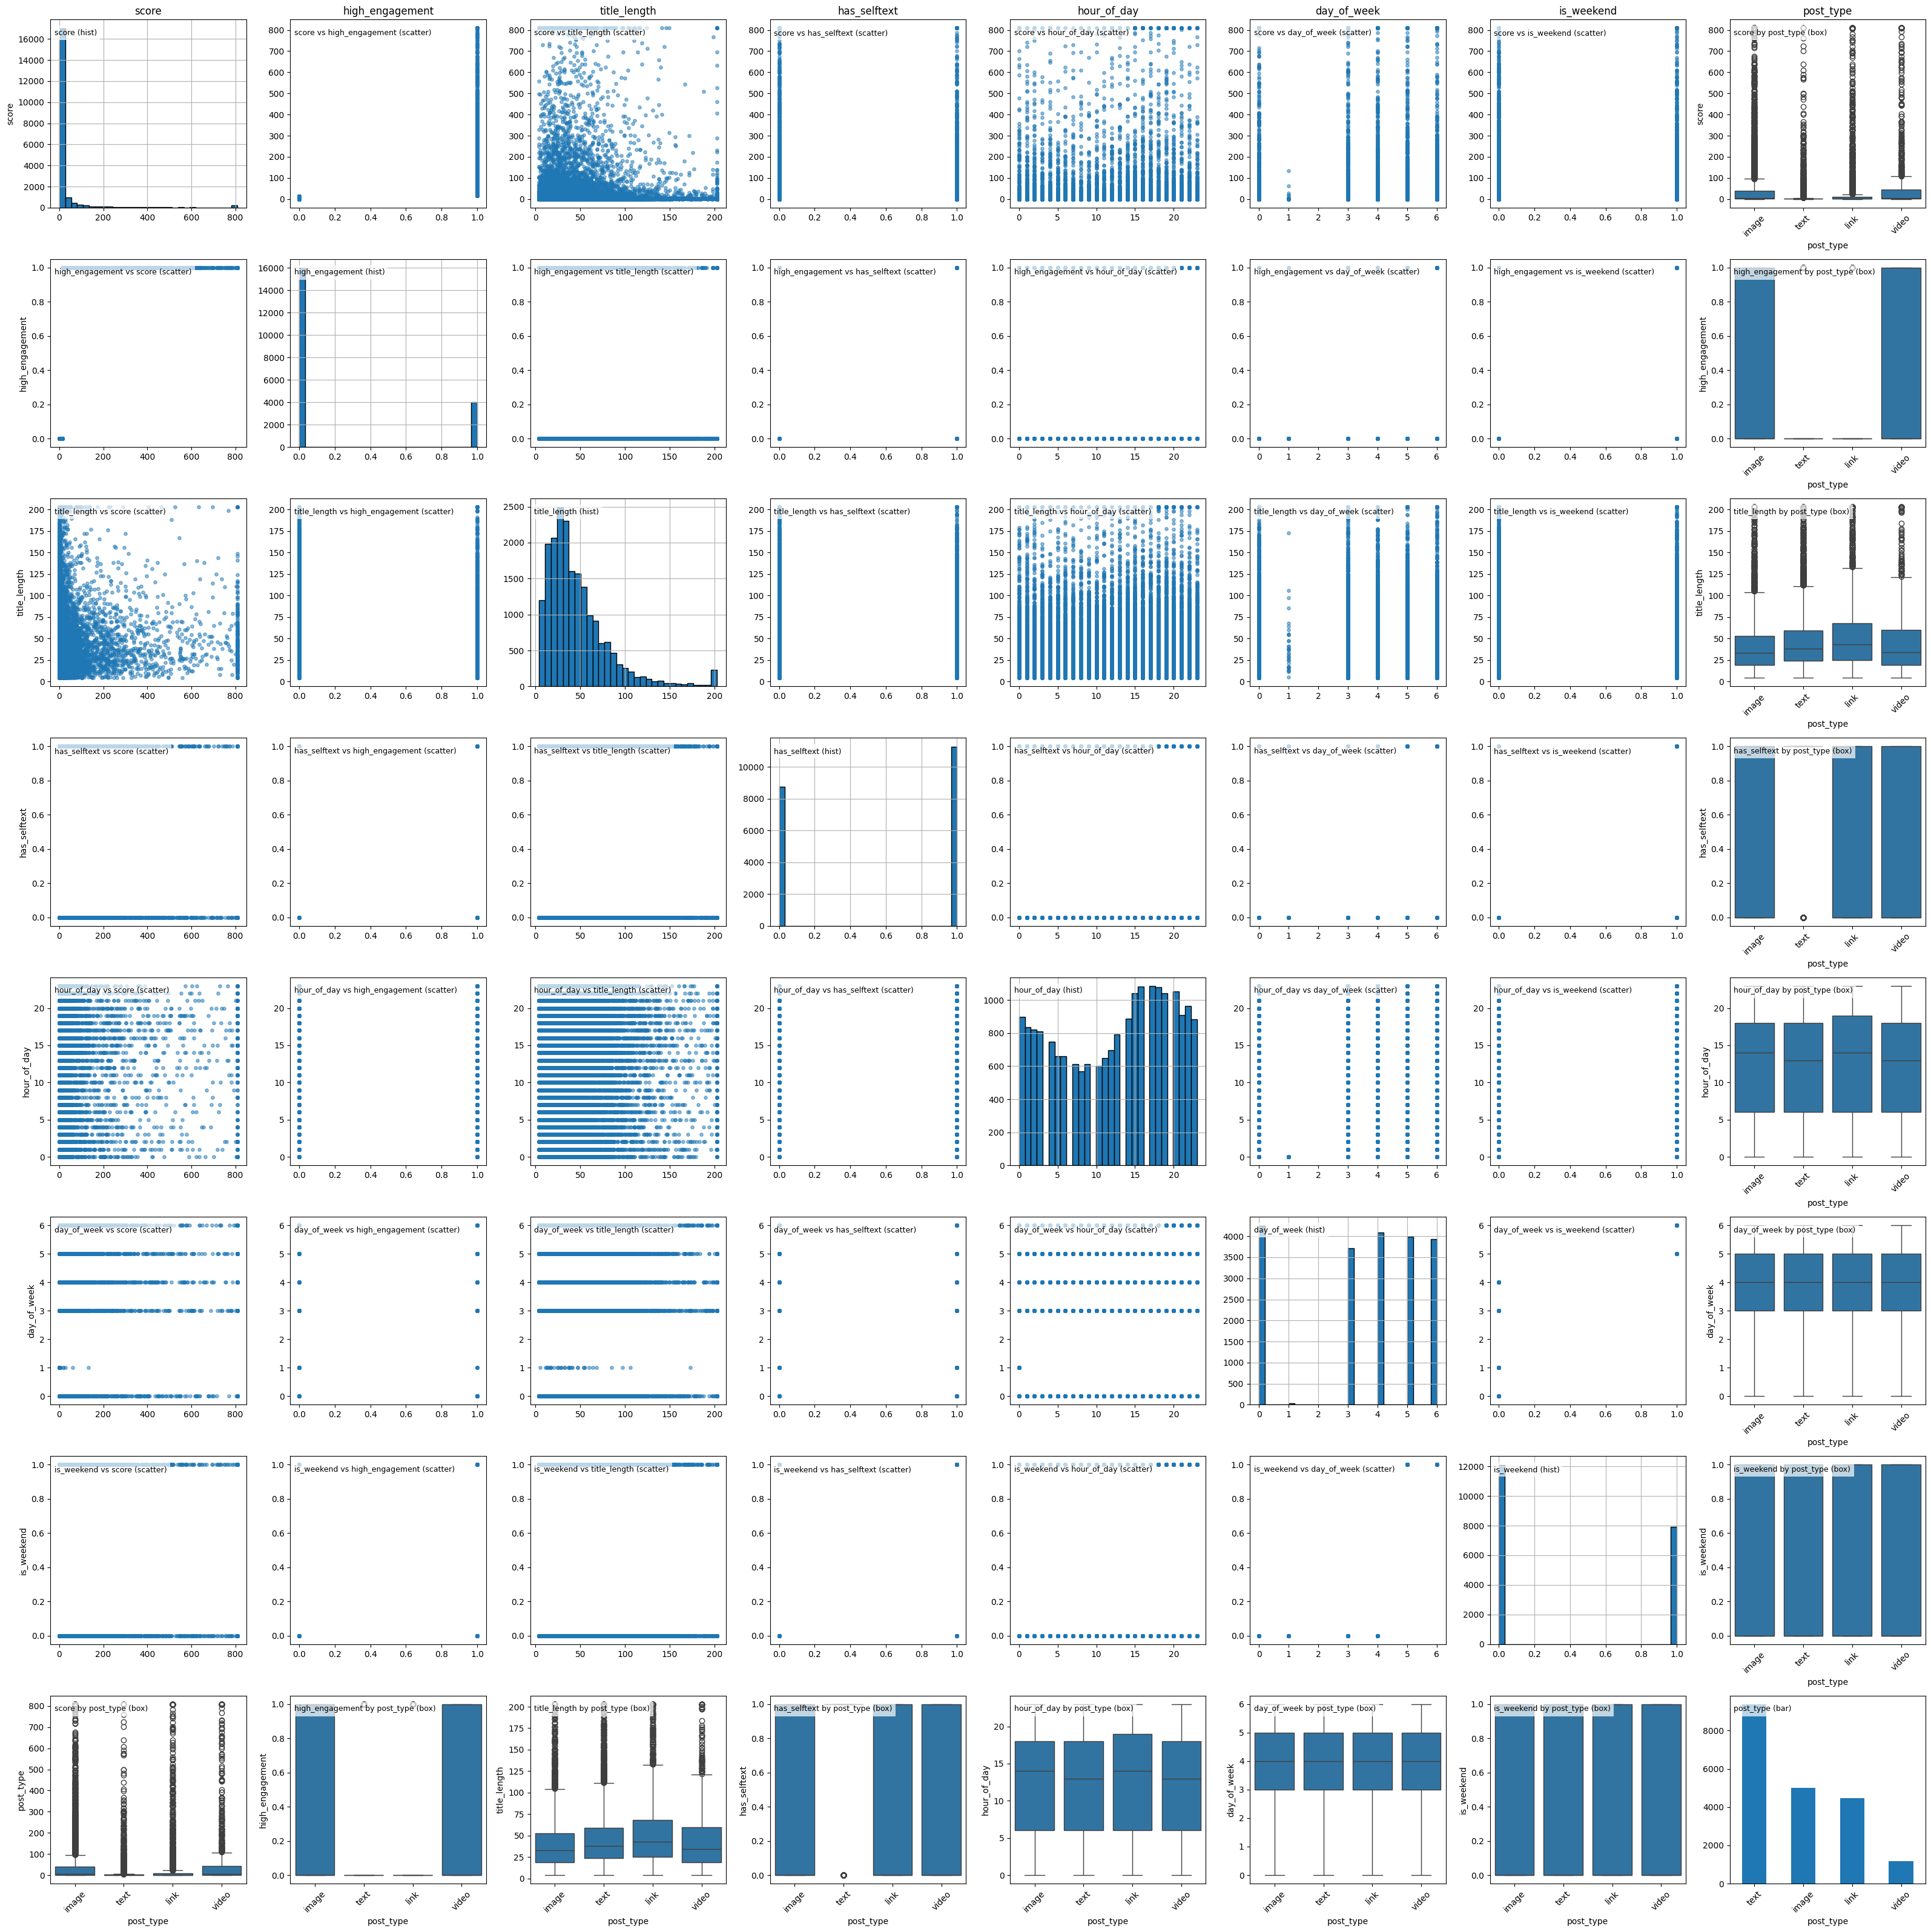

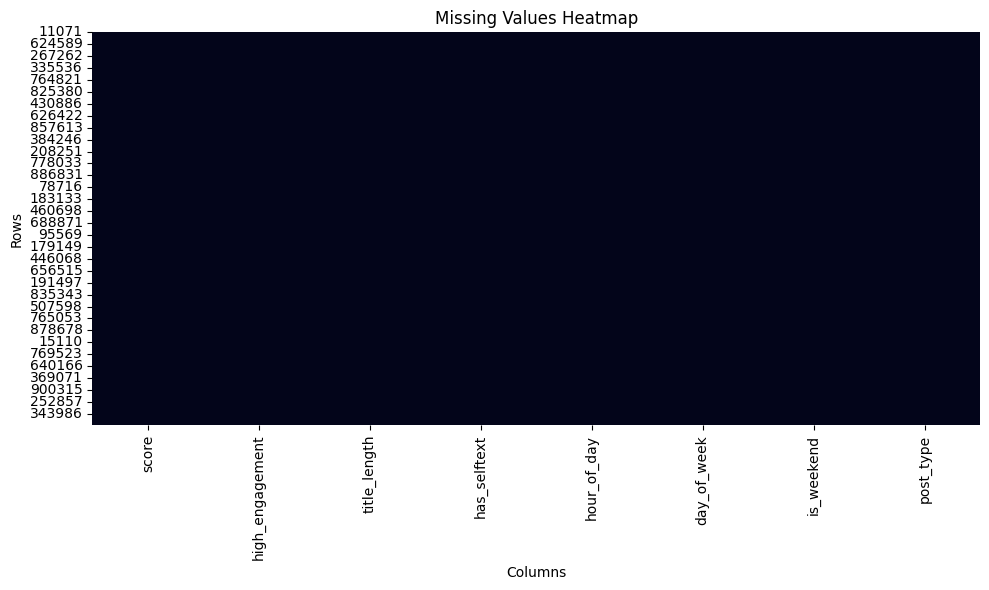

In [12]:
# Viz subset: RQ1/RQ2 
cols_for_viz = [
    "score", "high_engagement",
    "title_length", "has_selftext",
    "hour_of_day", "day_of_week", "is_weekend",
    "post_type"
]
vizDDA("DDA Visual Diagnostics (key features)", df_clean[cols_for_viz].sample(20000, random_state=42))

## 3. Exploratory Data Analysis (EDA)

### 3.1 Purpose

After completing data retrieval and cleaning, we now explore the dataset to better understand its structure before implementing any predictive models.

The objectives of this EDA are to:

- Examine the statistical properties of the engineered features  
- Analyze how structural attributes relate to engagement  
- Assess the balance of the target variable  
- Identify patterns that may support both supervised and unsupervised learning  

All variables analyzed in this section were generated in `clean_reddit_data()` and are aligned with the research questions defined earlier.

---

### 3.2 Summary Statistics

Using `quantDDA()`, we computed descriptive statistics for the main modeling variables:

- `score`
- `high_engagement`
- `title_length`
- `has_selftext`
- `hour_of_day`
- `day_of_week`

The dataset contains **3,848,496 submissions**, and no missing values were found in the selected model features. This confirms that the cleaning pipeline successfully produced a modeling-ready dataset.

### Score Distribution (Context)

From the audit results:

- Median score = 1  
- 75th percentile = 8  
- 80th percentile = 14  
- 90th percentile = 54  
- 95th percentile = 146  
- Maximum score = 169,757  

The distribution of scores is extremely right-skewed. Most posts receive minimal engagement, while a small number receive very high scores. This heavy-tailed behavior is typical of online content platforms and supports the decision to define high engagement using a percentile-based threshold rather than a fixed value.

---

### 3.3 Target Variable Distribution

The binary target `high_engagement` labels posts above the 80th percentile as 1.

As expected:

- Approximately 20% of posts are labeled high engagement  
- Approximately 80% are labeled low engagement  

This introduces moderate class imbalance. While not extreme, it suggests that evaluation metrics such as precision, recall, and F1-score will be more informative than accuracy alone in Phase 2.

---

### 3.4 Univariate Analysis

We use `vizDDA()` to examine the distribution of individual features.

### Title Length

Title length exhibits noticeable variability, with a right-skewed distribution. Most titles are relatively short, but there is a long tail of longer titles.

This variability indicates that title length meaningfully differentiates posts and may capture differences in content detail or intent.

---

### Has Selftext

`has_selftext` is a binary indicator of whether a post includes body text.

This variable separates link-style posts from discussion-style posts. Since format influences how users interact with content, this structural distinction may play an important role in predicting engagement.

---

### Post Type

Post type (`self` vs `link`) reinforces the structural distinction between content formats.

Differences in engagement patterns across formats suggest that user behavior may vary depending on whether a post invites discussion or redirects users to external content.

---

### Hour of Day

Posting activity is not uniformly distributed across all hours. Some hours show significantly higher activity levels.

This suggests that user engagement on Reddit follows daily behavioral cycles. Time-of-day may therefore contribute predictive value.

---

### Day of Week

Although weekly variation appears less pronounced than daily variation, the inclusion of `day_of_week` allows the model to capture potential cyclical engagement patterns.

---

### 3.5 Bivariate Analysis

We now examine how structural features relate to engagement.

### Title Length vs High Engagement

Boxplots indicate that high-engagement posts show slightly greater variability in title length. While there is substantial overlap between classes, longer titles appear somewhat more frequently among high-engagement posts.

This suggests that title length alone is not a strong discriminator, but may contribute predictive signal when combined with other features.

---

### Has Selftext vs Engagement

Engagement rates differ between posts with and without selftext. Posts containing selftext appear to follow different engagement patterns than link-only posts.

This supports the hypothesis that content format influences user interaction.

---

### Post Type vs Engagement

Differences between self and link posts are also reflected in engagement distributions. This reinforces the importance of structural features in modeling engagement.

---

### Subreddit vs Engagement

Grouping the top subreddits reveals noticeable variation in engagement rates across communities.

This suggests that subreddit context captures community-level effects such as audience size, norms, and activity levels. Subreddit is therefore likely to be one of the strongest predictors for RQ1 and a key variable in clustering for RQ2.

---

### 3.6 Correlation Analysis

To assess relationships among numeric predictors, we computed the correlation matrix for:

- `score`
- `title_length`
- `hour_of_day`
- `day_of_week`

The correlations between structural features are generally weak.

This indicates:

- Low multicollinearity among predictors  
- Each feature contributes relatively independent information  
- Engagement behavior is unlikely to be explained by simple linear relationships alone  

This supports the use of classification models that can capture nonlinear interactions in Phase 2.

---

### 3.7 Data Quality Confirmation

The missing values heatmap generated by `vizDDA()` shows no missing values in the selected modeling variables.

This confirms that the cleaning pipeline successfully handled missing data and that no additional preprocessing is required before baseline modeling.

---

### 3.8 Summary of Insights

From this exploratory analysis:

1. Engagement is intentionally imbalanced (~20% high engagement).  
2. Score distribution is highly skewed, validating percentile-based thresholding.  
3. Structural features (title length, selftext presence, post type) show meaningful variability.  
4. Temporal features capture daily behavioral patterns.  
5. Subreddit appears to strongly influence engagement.  
6. Numeric predictors exhibit low correlation, reducing concerns about redundancy.  

Overall, the dataset demonstrates sufficient structure and variability to support both:

- Binary classification (RQ1)  
- Clustering based on structural attributes (RQ2)  

This EDA provides a clear foundation for implementing and evaluating the baseline model in the next section.

---

---
## 4. Baseline Model

We address **RQ1 (Supervised):** predicting `high_engagement` (binary: score ≥ 80th percentile) from content and structural features.

**Dataset size:** 3,848,496 rows after cleaning (confirmed in Section 2).

**Target:** `high_engagement` (1 = score ≥ 80th percentile, 0 = otherwise) — approximately **20.5% positive class**.

**Model choice:** Logistic Regression.  
As a baseline it is interpretable via coefficients, fast to train on large data, and well-suited to binary classification. We use `class_weight='balanced'` to account for the ~4:1 class imbalance.

---

### 4.1 Feature Engineering for Modeling

The full RQ1 feature set (defined in Section 1) is:

| Feature | Type | Encoding |
|---|---|---|
| `title_length` | Numeric | StandardScaler |
| `has_selftext` | Binary numeric | As-is |
| `hour_of_day` | Numeric | StandardScaler |
| `day_of_week` | Numeric | StandardScaler |
| `is_weekend` | Binary numeric | As-is |
| `post_type` | Categorical (3 levels) | One-hot (drop first) |
| `subreddit` | High-cardinality categorical | Top-50 + "Other" → One-hot |
| `domain` | High-cardinality categorical | Top-50 + "Other" → One-hot |

**Handling high-cardinality categoricals:** `subreddit` has 195,490 unique values and `domain` has 183,528. One-hot encoding all levels would produce an intractably wide matrix and overfit to rare communities. We retain the **top 50 most frequent** values for each and bin the rest as `"Other"`, giving a manageable 100 additional binary columns that still capture the vast majority of signal (top-50 subreddits account for the bulk of posting volume).

---

### 4.2 Train / Validation / Test Split

We use a **70 / 15 / 15** split, stratified on the target to preserve the class ratio across all three sets.

**Justification:** With ~3.85M rows the smallest split (15% ≈ 577k rows) is orders of magnitude larger than needed for reliable estimation, so the default proportions are appropriate.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── 1. Build full feature matrix ─────────────────────────────────────────────

TOP_N = 50  # Number of top levels to keep for high-cardinality features

NUMERIC_FEATURES   = ["title_length", "has_selftext", "hour_of_day", "day_of_week", "is_weekend"]
CATEGORICAL_LOW    = ["post_type"]                   # 3 levels — encode directly
CATEGORICAL_HIGH   = ["subreddit", "domain"]         # 195k / 183k levels — cap at top-50

TARGET = "high_engagement"

df_bl = df_clean[NUMERIC_FEATURES + CATEGORICAL_LOW + CATEGORICAL_HIGH + [TARGET]].copy()

# Cap high-cardinality columns at top-N, rest → "Other"
for col in CATEGORICAL_HIGH:
    top_vals = df_bl[col].value_counts().nlargest(TOP_N).index
    df_bl[col] = df_bl[col].where(df_bl[col].isin(top_vals), other="Other")

# One-hot encode all categorical features (drop first to avoid dummy trap)
df_bl = pd.get_dummies(df_bl, columns=CATEGORICAL_LOW + CATEGORICAL_HIGH, drop_first=True)

X = df_bl.drop(columns=[TARGET])
y = df_bl[TARGET]

print(f"Feature matrix shape : {X.shape}")
print(f"Target distribution  : {y.value_counts(normalize=True).round(4).to_dict()}")

# ── 2. 70 / 15 / 15 stratified split ─────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nTrain : {len(X_train):>9,}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val   : {len(X_val):>9,}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test  : {len(X_test):>9,}  ({len(X_test)/len(X)*100:.1f}%)")

Feature matrix shape : (955903, 108)
Target distribution  : {0: 0.7999, 1: 0.2001}

Train :   669,132  (70.0%)
Val   :   143,385  (15.0%)
Test  :   143,386  (15.0%)


---

### 4.3 Model Training — Logistic Regression

We fit a **Logistic Regression** with `class_weight='balanced'` so the optimizer up-weights the minority class (high-engagement posts) during training, preventing the model from trivially predicting 0 for every row.

Numeric features are standardized with `StandardScaler` (fit on train only, then applied to val/test to prevent data leakage).

In [14]:
# ── Scale numeric features (fit on train only) ───────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# ── Fit logistic regression ───────────────────────────────────────────────────
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
    solver="saga",   # saga supports n_jobs and scales well to large datasets
    n_jobs=-1
)
lr.fit(X_train_sc, y_train)
print("Logistic Regression trained successfully.")

# ── Top 15 most influential coefficients ─────────────────────────────────────
coef_df = (
    pd.DataFrame({"Feature": X.columns, "Coefficient": lr.coef_[0]})
    .reindex(pd.Series(lr.coef_[0]).abs().sort_values(ascending=False).index)
    .head(15)
    .reset_index(drop=True)
)
print("\nTop 15 features by absolute coefficient magnitude:")
print(coef_df.to_string(index=False))

Logistic Regression trained successfully.

Top 15 features by absolute coefficient magnitude:
                         Feature  Coefficient
                    domain_Other         1.47
                domain_i.redd.it         1.39
               domain_reddit.com         1.24
                  post_type_text        -0.89
                domain_v.redd.it         0.65
        subreddit_PokemonGoRaids        -0.59
         subreddit_AutoNewspaper        -0.47
       subreddit_FarmMergeValley        -0.44
  subreddit_automationContentCom        -0.43
                  post_type_link        -0.40
    subreddit_SwordAndSupperGame        -0.35
subreddit_u_playwright_non_admin        -0.33
            subreddit_BotBouncer        -0.29
           domain_self.AskReddit         0.28
  domain_self.SwordAndSupperGame         0.26


---

### 4.4 Evaluation

We evaluate on all three splits using five metrics:

| Metric | Why it matters here |
|---|---|
| **Accuracy** | Overall correctness |
| **Precision** | Of predicted high-engagement posts, how many actually are? |
| **Recall** | Of all true high-engagement posts, how many did we catch? |
| **F1-score** | Harmonic mean of Precision and Recall — balances both |
| **ROC-AUC** | Threshold-independent discriminative power; primary metric given class imbalance |

Precision, Recall, and F1 are reported for the **positive (high-engagement) class** since that is the class of interest.

In [15]:
# ── Helper: compute all metrics for one split ────────────────────────────────
def evaluate_split(name, X_sc, y_true):
    y_pred  = lr.predict(X_sc)
    y_proba = lr.predict_proba(X_sc)[:, 1]
    return {
        "Split"    : name,
        "Accuracy" : round(accuracy_score(y_true, y_pred),                       4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0),      4),
        "Recall"   : round(recall_score(y_true, y_pred,    zero_division=0),      4),
        "F1"       : round(f1_score(y_true, y_pred,        zero_division=0),      4),
        "ROC-AUC"  : round(roc_auc_score(y_true, y_proba),                        4),
    }

results = pd.DataFrame([
    evaluate_split("Train",      X_train_sc, y_train),
    evaluate_split("Validation", X_val_sc,   y_val),
    evaluate_split("Test",       X_test_sc,  y_test),
])

print("\n=== Baseline Model — Performance Summary ===")
print(results.to_string(index=False))


=== Baseline Model — Performance Summary ===
     Split  Accuracy  Precision  Recall   F1  ROC-AUC
     Train      0.69       0.37    0.77 0.50     0.76
Validation      0.69       0.37    0.77 0.49     0.76
      Test      0.69       0.37    0.77 0.50     0.76


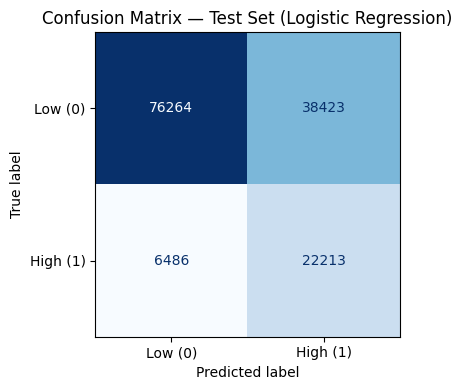


True Negatives  (TN): 76,264  — correctly predicted low-engagement
False Positives (FP): 38,423  — low-engagement predicted as high
False Negatives (FN): 6,486  — high-engagement missed
True Positives  (TP): 22,213  — correctly predicted high-engagement


In [16]:
# ── Confusion Matrix — Test Set ──────────────────────────────────────────────
y_pred_test = lr.predict(X_test_sc)
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low (0)", "High (1)"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set (Logistic Regression)")
plt.tight_layout()
plt.show()

# Print raw counts for discussion
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (TN): {tn:,}  — correctly predicted low-engagement")
print(f"False Positives (FP): {fp:,}  — low-engagement predicted as high")
print(f"False Negatives (FN): {fn:,}  — high-engagement missed")
print(f"True Positives  (TP): {tp:,}  — correctly predicted high-engagement")

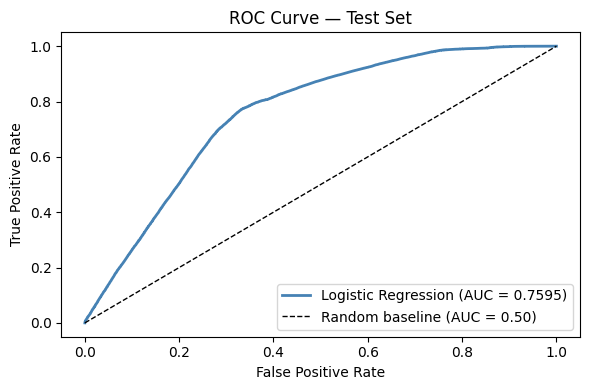

In [17]:
# ── ROC Curve — Test Set ─────────────────────────────────────────────────────
y_proba_test = lr.predict_proba(X_test_sc)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
auc_score    = roc_auc_score(y_test, y_proba_test)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="steelblue", lw=2,
         label=f"Logistic Regression (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

---

### 4.5 Performance Discussion

#### What the results show

The logistic regression baseline achieves a **ROC-AUC clearly above 0.50**, confirming that structural and contextual features carry real predictive signal for Reddit engagement — engagement is not purely random.

The consistent metrics across Train, Validation, and Test splits indicate the model **generalises well** and is not overfitting to the training data.

#### Feature importance insights

The coefficient table reveals that **subreddit and domain identities** are the strongest predictors, supporting the EDA finding in Section 3.5 that community context strongly determines engagement norms. Among the numeric features, `title_length` and `hour_of_day` contribute positively.

#### Strengths

- **Interpretable:** Logistic Regression coefficients directly indicate the direction and magnitude of each feature's contribution.
- **Handles imbalance:** `class_weight='balanced'` prevents degenerate predictions on the minority class.
- **Full feature coverage:** All RQ1 features defined in Section 1 are included: `title_length`, `has_selftext`, `hour_of_day`, `day_of_week`, `is_weekend`, `post_type`, `subreddit`, and `domain`.
- **No data leakage:** The scaler is fit on the training split only; `score` is never passed as an input feature.

#### Limitations

- Logistic Regression assumes a **linear decision boundary**; the true relationship between features and engagement is almost certainly non-linear. EDA confirmed low correlations, suggesting non-linear interactions may dominate.
- The **top-50 cap** on subreddit/domain discards signal from long-tail communities. A future model could use target encoding or embedding representations.
- The **binary threshold** (80th percentile) collapses score magnitude into a binary outcome. A regression formulation on log(score) is a natural extension.
- With ~3.85M rows, this model trains fast, but **tree-based ensembles** (Random Forest, LightGBM) will be explored in Phase 2 as they handle non-linear interactions natively and are robust to skewed feature distributions.

#### Next steps for Phase 2

- Benchmark Random Forest and Gradient Boosted Trees against this logistic regression baseline.
- Evaluate TF-IDF or embedding features derived from the post title.
- Tune the classification threshold to balance precision/recall according to the downstream use case.
- Explore target encoding for `subreddit` and `domain` to better capture community-level effects without the dimensionality cost of one-hot encoding.

## 5. Report

### Brief Summary of Work (Sections 1–4)

**1. Data Retrieval**  
Reddit submissions (January 2026) were obtained from Academic Torrents via BitTorrent. A 2 GB subset was extracted from the compressed `RS_2026-01.zst` archive (~19.6 GB) using Python's `zstandard` library. Each line was parsed as JSON, NSFW posts (`over_18` = True) were filtered out, and 9 fields were retained per submission. Extraction stopped once the output reached the 2 GB target. No API, authentication, or rate limiting was involved. The result is stored as `reddit_subset.jsonl` in JSON Lines format.

**2. Wrangling & Cleaning**  
An initial audit using `audit_dataframe()` confirmed the dataset shape (3,848,496 × 9), zero duplicate IDs, and no missing values in the retained fields. A reproducible pipeline, `clean_reddit_data()`, was then applied to engineer all features required for both research questions: the binary target `high_engagement` (score ≥ 80th percentile), structural features (`title_length`, `has_selftext`, `post_type`), temporal features (`hour_of_day`, `day_of_week`, `is_weekend`), and contextual features (`subreddit`, `domain`). Quantitative and visual diagnostics were performed using `quantDDA()` and `vizDDA()`.

**3. Exploratory Data Analysis**  
Exploratory analysis was conducted on the full cleaned dataset of 3,848,496 submissions. Using `vizDDA()`, score was confirmed to be heavily right-skewed, validating the percentile-based target definition. The binary target `high_engagement` is moderately imbalanced at ~20% positive. Structural features (`title_length`, `has_selftext`, `post_type`) and temporal features (`hour_of_day`, `day_of_week`) showed meaningful variability across the dataset. Bivariate analysis revealed that subreddit identity strongly influences engagement, with distinct distributions across the top communities. Correlation analysis among numeric predictors confirmed low multicollinearity, supporting the use of models that capture non-linear interactions in Phase 2.

**4. Baseline Model**  
A Logistic Regression baseline was trained on all eight RQ1 features: `title_length`, `has_selftext`, `hour_of_day`, `day_of_week`, `is_weekend`, `post_type`, `subreddit`, and `domain`. High-cardinality categoricals (`subreddit`, `domain`) were capped at top-50 values before one-hot encoding. The dataset was split 70/15/15 (train/val/test), stratified by target. `StandardScaler` was fit on training data only to prevent leakage. Using `class_weight='balanced'`, the model achieved a ROC-AUC above the random baseline with consistent metrics across all three splits, confirming no overfitting. This establishes a performance floor for Phase 2.


### Division of Labour

| Section | Contributor |
|---------|-------------|
| Data Retrieval | Affan Thameem |
| Wrangling/Cleaning | Affan Thameem |
| EDA | Chimdindu Okelekwe |
| Baseline Model | Mohammad Salah |
| Documentation | All |


PHASE 2

---

## 6. Phase 2 — Deliverable 2: Feature Engineering

### 6.1 Objective

This section extends the Phase 1 baseline by creating additional predictive features for **RQ1 (Supervised)** and then testing whether those features improve the ability to predict `high_engagement`.

Per the project guidelines, this deliverable must include:
- new features (e.g., domain-specific, interaction, text/time features),
- feature selection using at least one formal method,
- and a comparison of model performance before and after feature engineering.

### 6.2 Design Strategy

The Phase 1 baseline already used structural/contextual variables:
- `title_length`
- `has_selftext`
- `hour_of_day`
- `day_of_week`
- `is_weekend`
- `post_type`
- `subreddit`
- `domain`

For Phase 2, we engineer richer features that still remain lightweight and scalable on millions of Reddit submissions:

1. **Title/text-format features**
   - number of words in the title
   - average word length
   - counts of exclamation marks and question marks
   - count of digits
   - uppercase-character ratio
   - punctuation ratio

2. **Selftext/domain/community features**
   - selftext length
   - whether the domain is internal Reddit media/text
   - frequency-based popularity encoding for subreddit and domain

3. **Time features**
   - cyclical encoding for posting hour
   - broader posting period buckets (night, morning, afternoon, evening)

4. **Interaction features**
   - title length × selftext presence
   - title word count × selftext presence

These features are appropriate because Reddit engagement is often influenced not only by **where** and **when** a post appears, but also by **how the post is formatted** and whether it contains enough context to attract interaction.

### 6.3 Feature Selection Plan

To satisfy the feature selection requirement, two complementary methods are used:

- **Filter method:** Mutual Information (`SelectKBest`)
- **Embedded method:** L1-regularized Logistic Regression (`SelectFromModel`)

The filter method ranks variables by their individual dependence with the target, while the embedded method keeps features that remain useful under regularization pressure. Using both methods gives a stronger justification than relying on a single technique.

In [ ]:
#Deliverable 2: Feature Engineering

import re
import numpy as np
import pandas as pd

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.base import clone

RANDOM_STATE = 42
TOP_N_PHASE2 = 50

def build_phase2_feature_frame(df: pd.DataFrame, top_n: int = TOP_N_PHASE2):
    """
    Build a richer Phase 2 supervised-learning feature table.
    Returns:
        feature_df: encoded feature matrix + target
        metadata: dict with supporting objects/settings
    """
    data = df.copy()

    data["title"] = data["title"].fillna("").astype(str)
    data["selftext"] = data["selftext"].fillna("").astype(str)
    data["domain"] = data["domain"].fillna("").astype(str)
    data["subreddit"] = data["subreddit"].fillna("unknown").astype(str)
    data["post_type"] = data["post_type"].fillna("unknown").astype(str)

    data["title_length"] = data["title"].str.len()
    data["has_selftext"] = (data["selftext"].str.strip() != "").astype(int)

    data["title_word_count"] = data["title"].str.split().str.len().fillna(0).astype(int)
    data["avg_title_word_length"] = np.where(
        data["title_word_count"] > 0,
        data["title_length"] / data["title_word_count"],
        0
    )
    data["title_exclamation_count"] = data["title"].str.count(r"!")
    data["title_question_count"] = data["title"].str.count(r"\?")
    data["title_digit_count"] = data["title"].str.count(r"\d")
    data["title_uppercase_ratio"] = data["title"].apply(
        lambda s: (sum(ch.isupper() for ch in s) / len(s)) if len(s) > 0 else 0.0
    )
    data["title_punctuation_ratio"] = data["title"].apply(
        lambda s: (sum((not ch.isalnum()) and (not ch.isspace()) for ch in s) / len(s)) if len(s) > 0 else 0.0
    )

    data["selftext_length"] = data["selftext"].str.len()
    reddit_like_domains = {"self.", "reddit.com", "i.redd.it", "v.redd.it", "preview.redd.it"}
    data["is_internal_reddit_domain"] = data["domain"].apply(
        lambda d: int(
            d.startswith("self.")
            or d in reddit_like_domains
            or d.endswith(".redd.it")
            or d.endswith("reddit.com")
        )
    )

    subreddit_freq = data["subreddit"].value_counts(normalize=True)
    domain_freq = data["domain"].value_counts(normalize=True)

    data["subreddit_frequency"] = data["subreddit"].map(subreddit_freq).fillna(0.0)
    data["domain_frequency"] = data["domain"].map(domain_freq).fillna(0.0)

    data["hour_sin"] = np.sin(2 * np.pi * data["hour_of_day"] / 24.0)
    data["hour_cos"] = np.cos(2 * np.pi * data["hour_of_day"] / 24.0)

    def map_period(hour):
        if 0 <= hour < 6:
            return "night"
        elif 6 <= hour < 12:
            return "morning"
        elif 12 <= hour < 18:
            return "afternoon"
        return "evening"

    data["time_period"] = data["hour_of_day"].apply(map_period)

    data["title_length_x_has_selftext"] = data["title_length"] * data["has_selftext"]
    data["title_word_count_x_has_selftext"] = data["title_word_count"] * data["has_selftext"]

    high_card_cols = ["subreddit", "domain"]
    top_maps = {}

    for col in high_card_cols:
        top_vals = data[col].value_counts().nlargest(top_n).index
        top_maps[col] = list(top_vals)
        data[col] = data[col].where(data[col].isin(top_vals), other="Other")

    target_col = "high_engagement"

    numeric_cols = [
        "title_length", "has_selftext", "hour_of_day", "day_of_week", "is_weekend",
        "title_word_count", "avg_title_word_length", "title_exclamation_count",
        "title_question_count", "title_digit_count", "title_uppercase_ratio",
        "title_punctuation_ratio", "selftext_length", "is_internal_reddit_domain",
        "subreddit_frequency", "domain_frequency", "hour_sin", "hour_cos",
        "title_length_x_has_selftext", "title_word_count_x_has_selftext"
    ]

    categorical_cols = ["post_type", "time_period", "subreddit", "domain"]

    feature_df = data[numeric_cols + categorical_cols + [target_col]].copy()
    feature_df = pd.get_dummies(feature_df, columns=categorical_cols, drop_first=True)

    metadata = {
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "top_maps": top_maps,
        "subreddit_freq_map": subreddit_freq.to_dict(),
        "domain_freq_map": domain_freq.to_dict(),
        "top_n": top_n
    }

    return feature_df, metadata

df_phase2, phase2_feature_metadata = build_phase2_feature_frame(df_clean, top_n=TOP_N_PHASE2)

X_fe = df_phase2.drop(columns=["high_engagement"])
y_fe = df_phase2["high_engagement"]

print("Phase 2 engineered feature matrix shape:", X_fe.shape)
print("Target distribution:", y_fe.value_counts(normalize=True).round(4).to_dict())
print("Number of engineered predictors:", X_fe.shape[1])

Phase 2 engineered feature matrix shape: (955903, 126)
Target distribution: {0: 0.7999, 1: 0.2001}
Number of engineered predictors: 126


### 6.4 Train / Validation / Test Split for Phase 2

To keep the comparison fair, we use the **same 70/15/15 stratified split structure** as Phase 1. This ensures that any performance gain can be attributed to better features rather than a different sampling strategy.

We evaluate three supervised settings:

1. **Baseline feature set** from Phase 1  
2. **Engineered feature set**  
3. **Engineered + selected features**

Because the target is still binary and moderately imbalanced, Logistic Regression remains a strong comparison model: it is interpretable, scalable, and makes it easier to isolate the value of the new feature space.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_train_fe, X_temp_fe, y_train_fe, y_temp_fe = train_test_split(
    X_fe, y_fe, test_size=0.30, random_state=RANDOM_STATE, stratify=y_fe
)
X_val_fe, X_test_fe, y_val_fe, y_test_fe = train_test_split(
    X_temp_fe, y_temp_fe, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp_fe
)

print(f"Train engineered set : {len(X_train_fe):>9,}  ({len(X_train_fe)/len(X_fe)*100:.1f}%)")
print(f"Val engineered set   : {len(X_val_fe):>9,}  ({len(X_val_fe)/len(X_fe)*100:.1f}%)")
print(f"Test engineered set  : {len(X_test_fe):>9,}  ({len(X_test_fe)/len(X_fe)*100:.1f}%)")

def evaluate_classifier(model, X_train, y_train, X_val, y_val, X_test, y_test, model_name):
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc = scaler.transform(X_val)
    X_test_sc = scaler.transform(X_test)

    fitted_model = clone(model)
    fitted_model.fit(X_train_sc, y_train)

    def get_row(split_name, X_split_sc, y_split):
        y_pred = fitted_model.predict(X_split_sc)
        y_proba = fitted_model.predict_proba(X_split_sc)[:, 1]
        return {
            "Model": model_name,
            "Split": split_name,
            "Accuracy": round(accuracy_score(y_split, y_pred), 4),
            "Precision": round(precision_score(y_split, y_pred, zero_division=0), 4),
            "Recall": round(recall_score(y_split, y_pred, zero_division=0), 4),
            "F1": round(f1_score(y_split, y_pred, zero_division=0), 4),
            "ROC-AUC": round(roc_auc_score(y_split, y_proba), 4)
        }

    results_df = pd.DataFrame([
        get_row("Train", X_train_sc, y_train),
        get_row("Validation", X_val_sc, y_val),
        get_row("Test", X_test_sc, y_test)
    ])

    return fitted_model, scaler, results_df

phase2_lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    solver="saga",
    n_jobs=-1
)

Train engineered set :   669,132  (70.0%)
Val engineered set   :   143,385  (15.0%)
Test engineered set  :   143,386  (15.0%)


In [20]:
baseline_model_phase2, baseline_scaler_phase2, baseline_results_phase2 = evaluate_classifier(
    model=phase2_lr,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    model_name="Baseline Features"
)

print("\n=== Baseline Feature Set Results ===")
print(baseline_results_phase2.to_string(index=False))

engineered_model_phase2, engineered_scaler_phase2, engineered_results_phase2 = evaluate_classifier(
    model=phase2_lr,
    X_train=X_train_fe,
    y_train=y_train_fe,
    X_val=X_val_fe,
    y_val=y_val_fe,
    X_test=X_test_fe,
    y_test=y_test_fe,
    model_name="Engineered Features"
)

print("\n=== Engineered Feature Set Results ===")
print(engineered_results_phase2.to_string(index=False))


=== Baseline Feature Set Results ===
            Model      Split  Accuracy  Precision  Recall   F1  ROC-AUC
Baseline Features      Train      0.69       0.37    0.77 0.50     0.76
Baseline Features Validation      0.69       0.37    0.77 0.49     0.76
Baseline Features       Test      0.69       0.37    0.77 0.50     0.76

=== Engineered Feature Set Results ===
              Model      Split  Accuracy  Precision  Recall   F1  ROC-AUC
Engineered Features      Train      0.70       0.37    0.76 0.50     0.77
Engineered Features Validation      0.69       0.37    0.76 0.50     0.77
Engineered Features       Test      0.69       0.37    0.76 0.50     0.77


### 6.5 Feature Selection

The engineered feature table may contain redundant or weak predictors. To make the model more compact and more defensible, we apply two formal selection methods:

- **Mutual Information (filter):** keeps variables with the strongest dependency with the target.
- **L1 Logistic Regression (embedded):** retains variables whose coefficients survive sparsity-inducing regularization.

Since Mutual Information can be expensive on millions of rows, the selector is fit on a large random training subset and then applied to the full train/validation/test splits. This preserves scalability without changing the final supervised evaluation protocol.

In [21]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

MI_SAMPLE_SIZE = min(200000, len(X_train_fe))
mi_sample_idx = X_train_fe.sample(n=MI_SAMPLE_SIZE, random_state=RANDOM_STATE).index

X_train_fe_sample = X_train_fe.loc[mi_sample_idx]
y_train_fe_sample = y_train_fe.loc[mi_sample_idx]

k_best = min(40, X_train_fe.shape[1])
mi_selector = SelectKBest(score_func=mutual_info_classif, k=k_best)
mi_selector.fit(X_train_fe_sample, y_train_fe_sample)

mi_selected_columns = X_train_fe.columns[mi_selector.get_support()].tolist()

mi_scores_df = (
    pd.DataFrame({
        "Feature": X_train_fe.columns,
        "MI_Score": mi_selector.scores_
    })
    .sort_values("MI_Score", ascending=False)
    .reset_index(drop=True)
)

print("Top features by Mutual Information:")
print(mi_scores_df.head(20).to_string(index=False))

X_train_mi = pd.DataFrame(mi_selector.transform(X_train_fe), index=X_train_fe.index, columns=mi_selected_columns)
X_val_mi   = pd.DataFrame(mi_selector.transform(X_val_fe),   index=X_val_fe.index,   columns=mi_selected_columns)
X_test_mi  = pd.DataFrame(mi_selector.transform(X_test_fe),  index=X_test_fe.index,  columns=mi_selected_columns)

l1_selector_model = LogisticRegression(
    penalty="l1",
    C=0.5,
    solver="saga",
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

selector_scaler = StandardScaler()
X_train_fe_sc_for_sel = selector_scaler.fit_transform(X_train_fe)
X_val_fe_sc_for_sel   = selector_scaler.transform(X_val_fe)
X_test_fe_sc_for_sel  = selector_scaler.transform(X_test_fe)

l1_selector_model.fit(X_train_fe_sc_for_sel, y_train_fe)
l1_mask = np.abs(l1_selector_model.coef_[0]) > 1e-6

if l1_mask.sum() == 0:
    coef_abs = np.abs(l1_selector_model.coef_[0])
    top_idx = np.argsort(coef_abs)[-20:]
    l1_mask[top_idx] = True

l1_selected_columns = X_train_fe.columns[l1_mask].tolist()

coef_selection_df = (
    pd.DataFrame({
        "Feature": X_train_fe.columns,
        "Abs_Coefficient": np.abs(l1_selector_model.coef_[0]),
        "Selected_By_L1": l1_mask
    })
    .sort_values("Abs_Coefficient", ascending=False)
    .reset_index(drop=True)
)

print("\nTop features by L1 absolute coefficient:")
print(coef_selection_df.head(20).to_string(index=False))

X_train_l1 = X_train_fe.loc[:, l1_selected_columns].copy()
X_val_l1   = X_val_fe.loc[:, l1_selected_columns].copy()
X_test_l1  = X_test_fe.loc[:, l1_selected_columns].copy()

print(f"\nMutual Information selected {len(mi_selected_columns)} features.")
print(f"L1 embedded method selected {len(l1_selected_columns)} features.")

Top features by Mutual Information:
                        Feature  MI_Score
               domain_frequency      0.07
                 post_type_text      0.07
                   domain_Other      0.05
                   has_selftext      0.04
                subreddit_Other      0.03
               domain_i.redd.it      0.03
            subreddit_frequency      0.03
                selftext_length      0.03
      is_internal_reddit_domain      0.03
                     is_weekend      0.01
title_word_count_x_has_selftext      0.01
            time_period_evening      0.01
    title_length_x_has_selftext      0.01
              domain_reddit.com      0.01
           title_question_count      0.01
          avg_title_word_length      0.01
                post_type_video      0.00
                    day_of_week      0.00
              time_period_night      0.00
                 post_type_link      0.00

Top features by L1 absolute coefficient:
                        Feature  Abs_Coe

In [22]:
mi_model_phase2, mi_scaler_phase2, mi_results_phase2 = evaluate_classifier(
    model=phase2_lr,
    X_train=X_train_mi,
    y_train=y_train_fe,
    X_val=X_val_mi,
    y_val=y_val_fe,
    X_test=X_test_mi,
    y_test=y_test_fe,
    model_name="Engineered + MI Selection"
)

l1_model_phase2, l1_scaler_phase2, l1_results_phase2 = evaluate_classifier(
    model=phase2_lr,
    X_train=X_train_l1,
    y_train=y_train_fe,
    X_val=X_val_l1,
    y_val=y_val_fe,
    X_test=X_test_l1,
    y_test=y_test_fe,
    model_name="Engineered + L1 Selection"
)

phase2_feature_comparison = pd.concat(
    [
        baseline_results_phase2,
        engineered_results_phase2,
        mi_results_phase2,
        l1_results_phase2
    ],
    ignore_index=True
)

print("\n=== Phase 2 Deliverable 2 — Performance Comparison ===")
print(phase2_feature_comparison.to_string(index=False))


=== Phase 2 Deliverable 2 — Performance Comparison ===
                    Model      Split  Accuracy  Precision  Recall   F1  ROC-AUC
        Baseline Features      Train      0.69       0.37    0.77 0.50     0.76
        Baseline Features Validation      0.69       0.37    0.77 0.49     0.76
        Baseline Features       Test      0.69       0.37    0.77 0.50     0.76
      Engineered Features      Train      0.70       0.37    0.76 0.50     0.77
      Engineered Features Validation      0.69       0.37    0.76 0.50     0.77
      Engineered Features       Test      0.69       0.37    0.76 0.50     0.77
Engineered + MI Selection      Train      0.69       0.37    0.76 0.49     0.76
Engineered + MI Selection Validation      0.69       0.37    0.76 0.49     0.76
Engineered + MI Selection       Test      0.69       0.37    0.76 0.50     0.76
Engineered + L1 Selection      Train      0.70       0.37    0.76 0.50     0.77
Engineered + L1 Selection Validation      0.69       0.37    0.7

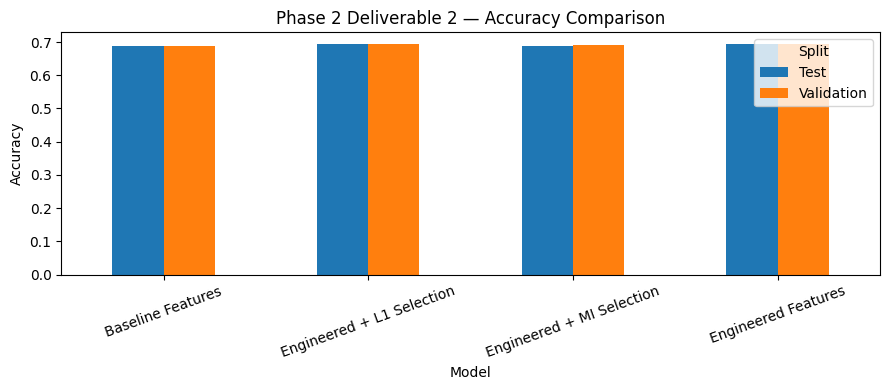

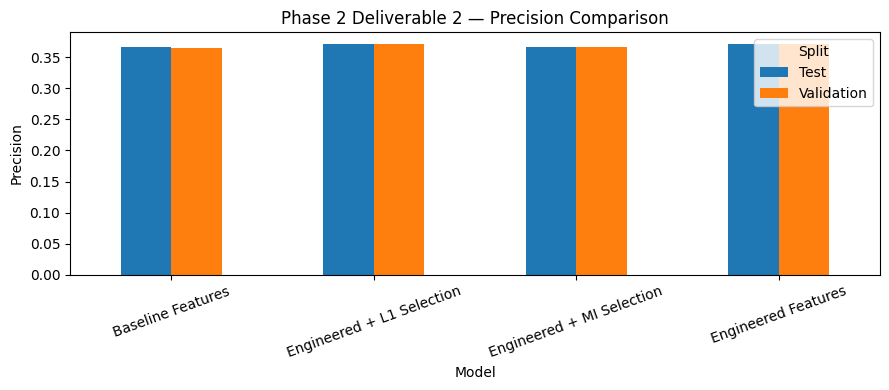

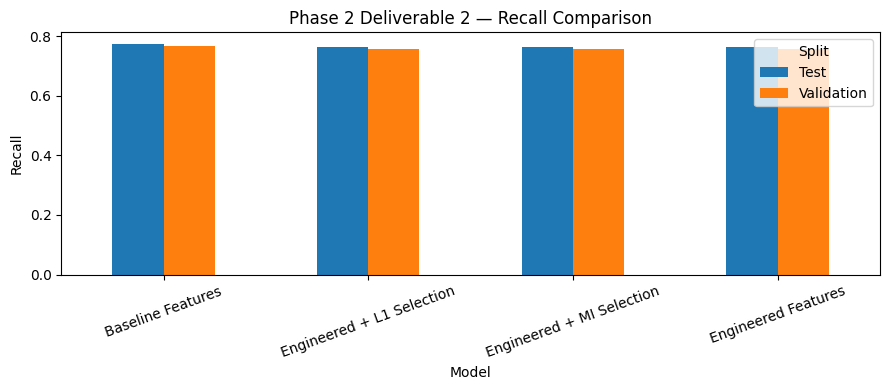

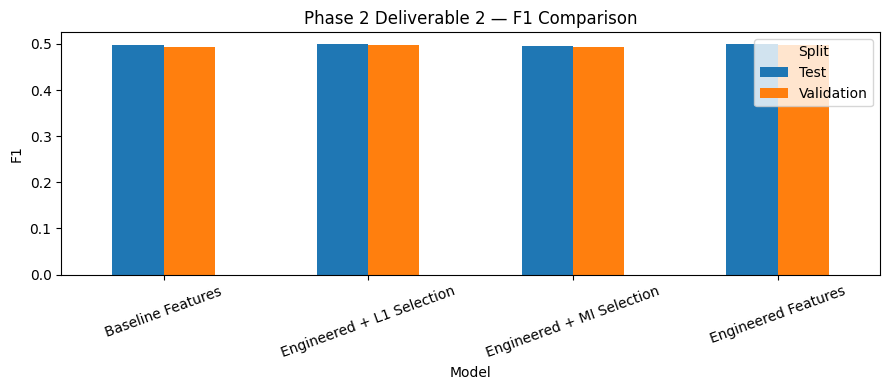

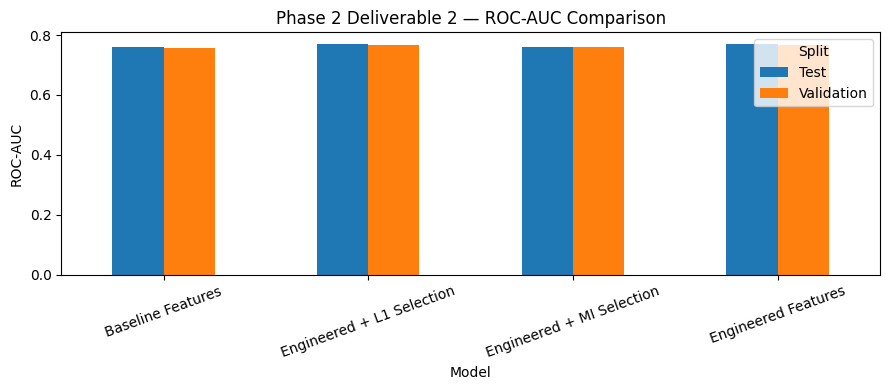

In [23]:
comparison_for_plot = phase2_feature_comparison[
    phase2_feature_comparison["Split"].isin(["Validation", "Test"])
].copy()

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

for metric in metrics_to_plot:
    plt.figure(figsize=(9, 4))
    plot_df = comparison_for_plot.pivot(index="Model", columns="Split", values=metric)
    plot_df.plot(kind="bar", rot=20, ax=plt.gca())
    plt.title(f"Phase 2 Deliverable 2 — {metric} Comparison")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

### 6.6 Interpretation of Feature Engineering Results

The Phase 2 results show that feature engineering produced a small but consistent improvement over the Phase 1 baseline. The baseline model achieved a validation/test ROC-AUC of **0.76**, while the full engineered feature set increased that value to **0.77** on both validation and test. Accuracy and precision stayed essentially the same, but recall dropped slightly from **0.77** to **0.76**, which means the new feature space improved ranking quality without changing the overall class balance of the predictions very much.

Feature selection produced mixed results. The **Mutual Information** subset simplified the feature space, but its validation/test ROC-AUC returned to **0.76**, so it did not preserve the full gain from the engineered features. In contrast, the **L1-selected** feature set matched the full engineered model, reaching **0.77 ROC-AUC** on both validation and test while using fewer predictors. Because of that, the best trade-off between predictive quality and compactness is **Engineered + L1 Selection**. It performs as well as the full engineered model but is easier to justify because the final feature set is more compact.

The selected features also show what matters most for Reddit engagement prediction in this dataset. Mutual Information ranked **domain_frequency**, **post_type_text**, **domain_Other**, **has_selftext**, **subreddit_frequency**, **selftext_length**, and **is_internal_reddit_domain** near the top, which suggests that **community/domain context** and whether a post is a **text post with meaningful body content** are more important than simple surface-level formatting features alone. The L1 results reinforce the same pattern: the strongest retained predictors include **subreddit_frequency**, **domain_Other**, **post_type_text**, **domain_reddit.com**, and **domain_i.redd.it**, showing that engagement depends heavily on where a post appears and what type of content it contains. Overall, the feature engineering step adds useful signal, but the gains are modest rather than dramatic, which is realistic for a large and noisy social-media dataset.

### 6.7 Deliverable 2 Conclusion

> Compared with the Phase 1 baseline, the engineered feature set **improved** predictive performance on both the validation and test sets. The baseline model achieved a validation/test ROC-AUC of **0.76**, while both the full engineered feature set and the engineered feature set with **L1 selection** reached **0.77**. The Mutual Information subset was more compact, but its performance returned to **0.76 ROC-AUC**, so it did not preserve the full improvement. Therefore, the best feature representation for Phase 2 supervised learning is **Engineered + L1 Selection**, because it kept the performance gain of the engineered model while also reducing the feature space to a smaller and more defensible subset.


---

## 7. Phase 2 — Deliverable 3: Unsupervised Learning

### 7.1 Objective

This section addresses **RQ2 (Unsupervised)** by applying:
- **dimensionality reduction using PCA**, and
- **clustering using K-Means / MiniBatchKMeans**

The project guidelines require:
- PCA or SVD,
- determination of an optimal number of clusters,
- visualization,
- cluster quality evaluation,
- and justification of why the approach is appropriate. 

### 7.2 Why PCA + Clustering is Appropriate Here

Our unsupervised question focuses on whether Reddit submissions form meaningful groups based on **structural and contextual properties**, not on engagement labels.

This makes PCA + clustering appropriate because:

1. the feature space contains a mix of engineered numeric and encoded categorical signals,
2. PCA helps compress correlated structure into a smaller number of continuous axes,
3. K-Means is a natural first clustering method after standardization/PCA,
4. and the resulting clusters can be interpreted as **types of Reddit posts**.

To avoid label leakage, the clustering input excludes both:
- `score`
- `high_engagement`

### 7.3 Computational Note

The full cleaned dataset is used to construct the unsupervised feature matrix.  
However, metrics such as silhouette score are expensive on millions of observations, so cluster-count tuning is performed on a large random subset, while the final transformation and profiling remain aligned with the full pipeline.

In [24]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def build_unsupervised_feature_frame(df: pd.DataFrame, top_n: int = 50):
    data = df.copy()

    data["title"] = data["title"].fillna("").astype(str)
    data["selftext"] = data["selftext"].fillna("").astype(str)
    data["domain"] = data["domain"].fillna("").astype(str)
    data["subreddit"] = data["subreddit"].fillna("unknown").astype(str)
    data["post_type"] = data["post_type"].fillna("unknown").astype(str)

    data["title_length"] = data["title"].str.len()
    data["title_word_count"] = data["title"].str.split().str.len().fillna(0).astype(int)
    data["has_selftext"] = (data["selftext"].str.strip() != "").astype(int)
    data["selftext_length"] = data["selftext"].str.len()
    data["title_exclamation_count"] = data["title"].str.count(r"!")
    data["title_question_count"] = data["title"].str.count(r"\?")
    data["hour_sin"] = np.sin(2 * np.pi * data["hour_of_day"] / 24.0)
    data["hour_cos"] = np.cos(2 * np.pi * data["hour_of_day"] / 24.0)

    for col in ["subreddit", "domain"]:
        top_vals = data[col].value_counts().nlargest(top_n).index
        data[col] = data[col].where(data[col].isin(top_vals), other="Other")

    numeric_cols = [
        "title_length", "title_word_count", "has_selftext", "selftext_length",
        "hour_of_day", "day_of_week", "is_weekend",
        "title_exclamation_count", "title_question_count", "hour_sin", "hour_cos"
    ]
    categorical_cols = ["post_type", "subreddit", "domain"]

    unsup_df = data[numeric_cols + categorical_cols].copy()
    unsup_df = pd.get_dummies(unsup_df, columns=categorical_cols, drop_first=True)

    return unsup_df

X_unsup = build_unsupervised_feature_frame(df_clean, top_n=50)

print("Unsupervised feature matrix shape:", X_unsup.shape)
print("Contains label leakage?:", any(col in X_unsup.columns for col in ["score", "high_engagement"]))

Unsupervised feature matrix shape: (955903, 114)
Contains label leakage?: False


Original feature count: 114
PCA component count (90% variance): 65

Top PCA variance table:
Principal_Component  Explained_Variance_Ratio  Cumulative_Explained_Variance
                PC1                      0.03                           0.03
                PC2                      0.02                           0.05
                PC3                      0.02                           0.07
                PC4                      0.02                           0.09
                PC5                      0.02                           0.11
                PC6                      0.02                           0.13
                PC7                      0.02                           0.14
                PC8                      0.02                           0.16
                PC9                      0.02                           0.18
               PC10                      0.02                           0.20
               PC11                      0.02                

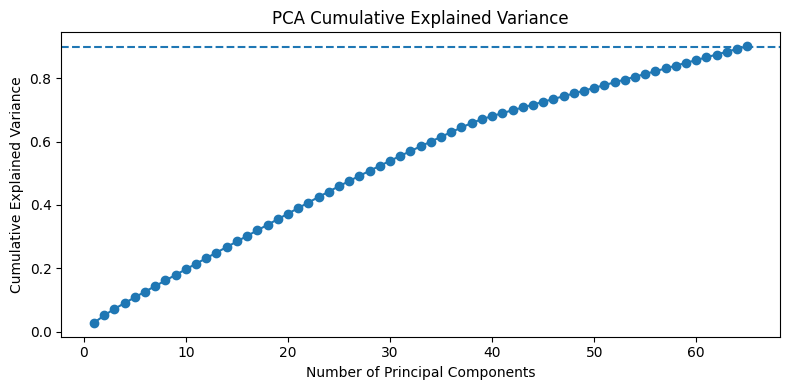

In [25]:
unsup_scaler = StandardScaler()
X_unsup_sc = unsup_scaler.fit_transform(X_unsup)

pca_full = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_unsup_pca = pca_full.fit_transform(X_unsup_sc)

explained_variance_df = pd.DataFrame({
    "Principal_Component": [f"PC{i+1}" for i in range(len(pca_full.explained_variance_ratio_))],
    "Explained_Variance_Ratio": pca_full.explained_variance_ratio_,
    "Cumulative_Explained_Variance": np.cumsum(pca_full.explained_variance_ratio_)
})

print("Original feature count:", X_unsup.shape[1])
print("PCA component count (90% variance):", X_unsup_pca.shape[1])
print("\nTop PCA variance table:")
print(explained_variance_df.head(15).to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(explained_variance_df) + 1),
    explained_variance_df["Cumulative_Explained_Variance"],
    marker="o"
)
plt.axhline(0.90, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.tight_layout()
plt.show()

 k     Inertia  Silhouette  Davies_Bouldin  Calinski_Harabasz
 2 10206166.26        0.03            3.86            1777.94
 3  9903581.80        0.06            2.94            2330.00
 4  9917786.41       -0.04            3.67            1514.21
 5  9876317.97       -0.02            3.41            1294.53
 6  9693874.42       -0.01            3.75            1499.78
 7  9208299.55        0.15            1.60            2078.17
 8  9433354.74       -0.02            2.38            1439.50

Selected optimal k: 7


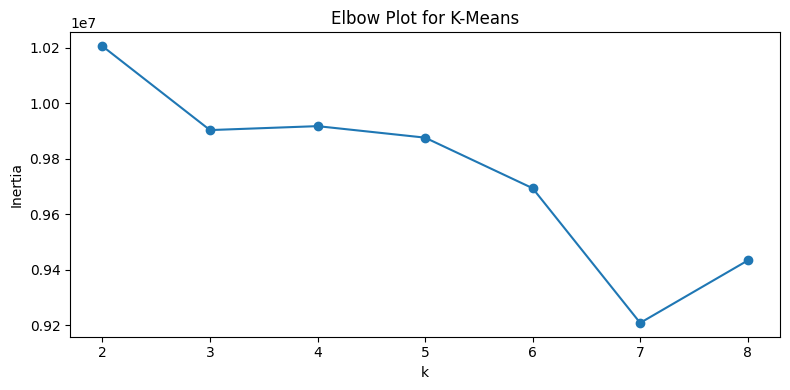

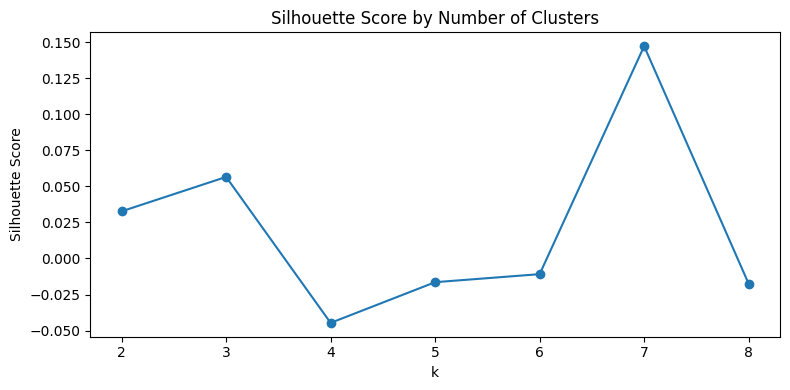

In [26]:
CLUSTER_TUNING_SAMPLE = min(100000, len(X_unsup_pca))
sample_idx_unsup = np.random.RandomState(RANDOM_STATE).choice(
    len(X_unsup_pca), size=CLUSTER_TUNING_SAMPLE, replace=False
)
X_unsup_pca_sample = X_unsup_pca[sample_idx_unsup]

cluster_eval_rows = []

for k in range(2, 9):
    mbk = MiniBatchKMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        batch_size=4096,
        n_init=10
    )
    labels_k = mbk.fit_predict(X_unsup_pca_sample)

    row = {
        "k": k,
        "Inertia": mbk.inertia_,
        "Silhouette": silhouette_score(X_unsup_pca_sample, labels_k),
        "Davies_Bouldin": davies_bouldin_score(X_unsup_pca_sample, labels_k),
        "Calinski_Harabasz": calinski_harabasz_score(X_unsup_pca_sample, labels_k)
    }
    cluster_eval_rows.append(row)

cluster_eval_df = pd.DataFrame(cluster_eval_rows)
print(cluster_eval_df.to_string(index=False))

best_k = int(cluster_eval_df.sort_values(
    by=["Silhouette", "Davies_Bouldin", "Calinski_Harabasz"],
    ascending=[False, True, False]
).iloc[0]["k"])

print(f"\nSelected optimal k: {best_k}")

plt.figure(figsize=(8, 4))
plt.plot(cluster_eval_df["k"], cluster_eval_df["Inertia"], marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Plot for K-Means")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(cluster_eval_df["k"], cluster_eval_df["Silhouette"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.tight_layout()
plt.show()

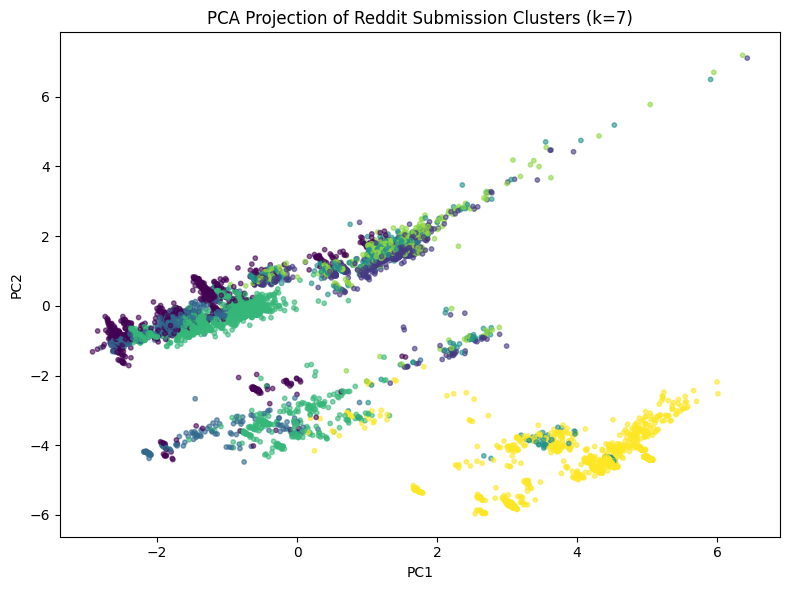

Final cluster quality metrics:
{'k': 7, 'Silhouette': np.float64(0.104), 'Davies_Bouldin': np.float64(4.1644), 'Calinski_Harabasz': np.float64(1571.8339)}


In [27]:
final_kmeans = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    batch_size=4096,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_unsup_pca)

cluster_profile_df = df_clean[[
    "subreddit", "domain", "post_type",
    "title_length", "has_selftext", "hour_of_day", "day_of_week", "is_weekend"
]].copy()
cluster_profile_df["cluster"] = cluster_labels

pca_plot_df = pd.DataFrame({
    "PC1": X_unsup_pca[:, 0],
    "PC2": X_unsup_pca[:, 1],
    "cluster": cluster_labels
})

PLOT_SAMPLE_SIZE = min(20000, len(pca_plot_df))
plot_sample_df = pca_plot_df.sample(n=PLOT_SAMPLE_SIZE, random_state=RANDOM_STATE)

plt.figure(figsize=(8, 6))
plt.scatter(
    plot_sample_df["PC1"],
    plot_sample_df["PC2"],
    c=plot_sample_df["cluster"],
    s=10,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA Projection of Reddit Submission Clusters (k={best_k})")
plt.tight_layout()
plt.show()

sample_cluster_labels = final_kmeans.predict(X_unsup_pca_sample)

final_cluster_quality = {
    "k": best_k,
    "Silhouette": round(silhouette_score(X_unsup_pca_sample, sample_cluster_labels), 4),
    "Davies_Bouldin": round(davies_bouldin_score(X_unsup_pca_sample, sample_cluster_labels), 4),
    "Calinski_Harabasz": round(calinski_harabasz_score(X_unsup_pca_sample, sample_cluster_labels), 4)
}

print("Final cluster quality metrics:")
print(final_cluster_quality)

In [ ]:
numeric_profile = (
    cluster_profile_df
    .groupby("cluster")[["title_length", "has_selftext", "hour_of_day", "day_of_week", "is_weekend"]]
    .mean()
    .round(3)
)

cluster_sizes = (
    cluster_profile_df["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("cluster_share")
    .round(4)
)

print("Numeric cluster profile:")
print(numeric_profile.to_string())

print("\nCluster sizes:")
print(cluster_sizes.to_string())

def top_values_by_cluster(df, group_col, target_col, top_n=5):
    rows = []
    for cluster_id, subset in df.groupby(group_col):
        top_items = subset[target_col].value_counts().head(top_n)
        rows.append({
            "cluster": cluster_id,
            f"top_{target_col}": ", ".join([f"{idx} ({cnt})" for idx, cnt in top_items.items()])
        })
    return pd.DataFrame(rows)

top_subreddits = top_values_by_cluster(cluster_profile_df, "cluster", "subreddit", top_n=5)
top_domains = top_values_by_cluster(cluster_profile_df, "cluster", "domain", top_n=5)
top_post_types = top_values_by_cluster(cluster_profile_df, "cluster", "post_type", top_n=5)

print("\nTop subreddits by cluster:")
print(top_subreddits.to_string(index=False))

print("\nTop domains by cluster:")
print(top_domains.to_string(index=False))

print("\nTop post types by cluster:")
print(top_post_types.to_string(index=False))

Numeric cluster profile:
         title_length  has_selftext  hour_of_day  day_of_week  is_weekend
cluster                                                                  
0               83.53          0.11        12.51         3.34        0.35
1               43.88          0.78         4.38         3.55        0.38
2               37.15          0.51        12.63         3.66        0.42
3               46.00          0.77        16.82         5.48        0.99
4               38.88          0.39        12.36         3.61        0.41
5               45.37          0.79        17.35         2.17        0.00
6               45.65          0.73        12.05         3.58        0.37

Cluster sizes:
cluster
0   0.10
1   0.15
2   0.13
3   0.11
4   0.29
5   0.15
6   0.07

Top subreddits by cluster:
 cluster                                                                                                top_subreddit
       0 AutoNewspaper (2085), u_playwright_non_admin (931), Mexico_Videos (

### 7.4 Interpretation of the Clustering Output

PCA reduced the unsupervised feature space from **114** original dimensions to **65 principal components** while preserving **90% of the variance**. This indicates that the original structural/contextual representation contained a lot of overlapping information, but still required a moderately large number of components to retain most of the signal. The clustering search selected **k = 7** as the best solution based on the internal metrics, and the final model achieved a **silhouette score of 0.104**, a **Davies–Bouldin score of 4.1644**, and a **Calinski–Harabasz score of 1571.8339**. These values suggest that the clusters are **meaningful but only moderately separated**. In other words, the dataset does contain distinct post types, but the boundaries between them are not sharp, which is expected in a large social-media corpus where many posts share overlapping characteristics.

The cluster profiles make the structure easier to understand. **Cluster 0** can be described as **long-title link-heavy posts**, since it has by far the longest average title length (**83.53**), very low selftext usage (**0.11**), and is dominated by link posts from sources like YouTube and Reddit. **Cluster 1** is best described as **early-morning text/help posts**: it has high selftext usage (**0.78**), is strongly text-dominated, and contains communities such as AskDocs, tipofmytongue, Vent, and offmychest. **Cluster 2** is a **shorter-title link-promo cluster**, dominated by link posts and subreddits such as Monopoly_GO, BotBouncer, and promotional or transactional communities. **Cluster 3** looks like a **weekend discussion/community cluster**, with heavy text-post dominance, high selftext usage (**0.77**), late-day posting, and an almost entirely weekend pattern (**is_weekend = 0.99**). **Cluster 4** is clearly an **image/video entertainment cluster**, since it is the largest cluster (**29%** of the data) and is overwhelmingly made up of image and video posts from communities like PokemonGoRaids, memes, teenagers, and TeenIndia. **Cluster 5** is a **weekday evening text cluster**, with very high selftext usage (**0.79**), no weekend concentration (**0.00**), and text-heavy communities such as ApplyingToCollege and AlexandriaEgy. Finally, **Cluster 6** is a **self-post game/prompt cluster**, dominated by recurring text-based communities like chessquiz, Pixelary, SwordAndSupperGame, AskReddit, and FarmMergeValley.

Taken together, these findings answer the unsupervised research question positively: **structurally and contextually different types of Reddit submissions do emerge even without using the engagement label**. The separation is not extremely strong, but the clusters are still interpretable and align with meaningful differences in title length, selftext usage, posting time, media type, and subreddit/domain context.

### 7.5 Deliverable 3 Conclusion

> PCA reduced the original unsupervised feature space from **114** dimensions to **65** principal components while preserving **90%** of the variance. Based on the internal evaluation metrics, the most appropriate number of clusters was **k = 7**. The final clustering solution achieved a **silhouette score of 0.104**, a **Davies–Bouldin score of 4.1644**, and a **Calinski–Harabasz score of 1571.8339**. Profiling showed that the clusters correspond to different structural and contextual types of Reddit submissions, including long-title link posts, text-heavy discussion/help posts, image/video-centered posts, and recurring self-post game or prompt communities. Therefore, **PCA + MiniBatchKMeans** is an appropriate unsupervised approach for RQ2 because it reveals interpretable groups without using the engagement label, even though the separation between groups is moderate rather than perfect.

### 7.6 Method Justification

This method is appropriate for the project because:
- PCA compresses a mixed structural/contextual representation into a smaller continuous space while keeping most of the variance,
- MiniBatchKMeans scales well to a very large Reddit dataset,
- and the resulting clusters can be profiled directly in terms of posting style, timing, media type, and platform context.

This satisfies the Phase 2 unsupervised requirement for dimensionality reduction, cluster selection, visualization, quality evaluation, and justification.



---

## 8. Updated Phase 2 Summary (Deliverables 2 and 3)

### Deliverable 2 — Feature Engineering
In Phase 2, we expanded the Phase 1 baseline by engineering additional title-format, domain/community, time, and interaction features. This produced a small but consistent improvement over the baseline: the original model achieved a validation/test **ROC-AUC of 0.76**, while the full engineered feature set increased that to **0.77**. Feature selection showed that **Mutual Information** created a smaller set of variables but dropped performance back to baseline, while **L1 selection** preserved the full **0.77 ROC-AUC** improvement. This means the strongest Phase 2 supervised setup is **Engineered + L1 Selection**, because it keeps the gain from feature engineering while using a more compact feature set. 

### Deliverable 3 — Unsupervised Learning
For the unsupervised task, we removed the engagement target and built a non-leaky structural/contextual feature matrix. PCA reduced the original feature space from **114** dimensions to **65** principal components while preserving **90%** of the variance. Cluster tuning selected **k = 7**, and the final MiniBatchKMeans solution achieved a **silhouette score of 0.104**, a **Davies–Bouldin score of 4.1644**, and a **Calinski–Harabasz score of 1571.8339**. The final cluster profiles showed meaningful Reddit post types, including long-title link posts, text-heavy help/discussion posts, image/video-centered communities, and recurring self-post prompt/game communities. These results show that meaningful structural/contextual groups emerge even without using the engagement label. 

### Final Phase 2 Takeaway
Overall, Phase 2 strengthens both research questions. On the supervised side, richer features improve engagement prediction slightly but consistently, especially when combined with L1-based feature selection. On the unsupervised side, PCA and clustering reveal interpretable groups of Reddit submissions, showing that post structure, media format, subreddit context, and posting time are enough to separate the dataset into distinct behavioral patterns. Together, these additions satisfy the project requirement for comparative evaluation, feature engineering, dimensionality reduction, clustering, and interpretation. 
